# Eye Disease Classification Using Fundus Images

This project develops a two-stage deep learning system for classifying eye diseases from fundus images.

The system consists of:
- Model 1: Normal vs Abnormal classification
- Model 2: Classification of 7 abnormal eye disease classes

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Copy of handout-50-question-level-test-advanced-32-answers.pdf',
 'uldd.pdf',
 'Personal photo.jpg',
 'يسر حسن محمود ابراهيم.jpg',
 'يسر حسن محمود ابراهيم.pdf',
 'Graduation certificate - NID - Military status..pdf',
 'يسر حسن محمود.pdf',
 'pledge يسر حسن محمود.pdf',
 'Yossr Hassan',
 'Untitled document.gdoc',
 'myPhoto.jpg',
 "Yosrr's CV.pdf",
 'Yossr Hassan Mahmoud Ibrahim.pdf',
 'cv_new (1).pdf',
 'call_center_cv.pdf',
 'cv_new.pdf',
 'WhatsApp Image 2026-04-09 at 1.35.16 AM.jpeg',
 'WhatsApp Image 2026-04-09 at 1.35.16 AM (1).jpeg',
 "Bachelor's Thesis.pdf",
 '89e5be88-a534-430f-a2a7-7aaa13e1036b.csv',
 '89e5be88-a534-430f-a2a7-7aaa13e1036b.gsheet',
 'Yossr_Hassan_CV.pdf',
 'Colab Notebooks',
 'EyeDiseaseDataset.zip']

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/EyeDiseaseDataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()

print("Number of files:", len(files))
print("\nFirst 30 files:")
for file in files[:30]:
    print(file)

Number of files: 11850

First 30 files:
splits/
splits/val.csv
metadata.csv
Tasks_and_Classes.md
catalog/
catalog/catalog_summary.csv
catalog/class_distribution.png
catalog/README.md
catalog/source_distribution.png
catalog/split_distribution.png
images/
images/ACRIMA_Im001_ACRIMA.jpg
images/ACRIMA_Im002_ACRIMA.jpg
images/ACRIMA_Im003_ACRIMA.jpg
images/ACRIMA_Im004_ACRIMA.jpg
images/ACRIMA_Im005_ACRIMA.jpg
images/ACRIMA_Im006_ACRIMA.jpg
images/ACRIMA_Im007_ACRIMA.jpg
images/ACRIMA_Im008_ACRIMA.jpg
images/ACRIMA_Im009_ACRIMA.jpg
images/ACRIMA_Im010_ACRIMA.jpg
images/ACRIMA_Im011_ACRIMA.jpg
images/ACRIMA_Im012_ACRIMA.jpg
images/ACRIMA_Im013_ACRIMA.jpg
images/ACRIMA_Im014_ACRIMA.jpg
images/ACRIMA_Im015_ACRIMA.jpg
images/ACRIMA_Im016_ACRIMA.jpg
images/ACRIMA_Im017_ACRIMA.jpg
images/ACRIMA_Im018_ACRIMA.jpg
images/ACRIMA_Im019_ACRIMA.jpg


In [ ]:
import zipfile
import pandas as pd
from io import TextIOWrapper

zip_path = '/content/drive/MyDrive/EyeDiseaseDataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    # Read metadata.csv directly from the ZIP
    with zip_ref.open('metadata.csv') as f:
        metadata = pd.read_csv(f)

print("Dataset shape:", metadata.shape)

print("\nColumns:")
print(metadata.columns.tolist())

print("\nFirst 5 rows:")
display(metadata.head())

Dataset shape: (11839, 4)

Columns:
['filename', 'dataset', 'unified_label', 'original_label']

First 5 rows:


,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal


In [ ]:
#metadata["original_label"].unique()
metadata["unified_label"].unique()

array(['Normal', 'Glaucoma', 'Diabetic Retinopathy', 'Cataract', 'Others',
       'Myopia', 'Hypertension', 'AMD'], dtype=object)

In [ ]:
print("Number of images in each class:")
print(metadata["unified_label"].value_counts())

Number of images in each class:
unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    split_files = [
        name for name in zip_ref.namelist()
        if name.startswith('splits/')
    ]

print("Files inside splits/:")
for file in split_files:
    print(file)

Files inside splits/:
splits/
splits/val.csv


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('splits/val.csv') as f:
        val_data = pd.read_csv(f)

print("Validation shape:", val_data.shape)

print("\nColumns:")
print(val_data.columns.tolist())

print("\nFirst 5 rows:")
display(val_data.head())

Validation shape: (1197, 4)

Columns:
['filename', 'dataset', 'unified_label', 'original_label']

First 5 rows:


,filename,dataset,unified_label,original_label
0,ODIR_2634_left.jpg,ODIR5K,Normal,N
1,ODIR_982_right.jpg,ODIR5K,Others,O
2,APTOS_image_02639.png,APTOS2019,Diabetic Retinopathy,DR
3,ACRIMA_Im309_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ODIR_2644_right.jpg,ODIR5K,Normal,N


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('Tasks_and_Classes.md') as f:
        content = f.read().decode('utf-8')

print(content)

# Eye Disease Dataset: Available Tasks & Class Descriptions

This document outlines the computer vision and machine learning tasks that can be accomplished using the unified Eye Disease Dataset, along with a detailed medical description of the 8 disease classes present in the corpus.

---

## Part 1: Available Machine Learning Tasks

Given the scale (11,839 images), diversity (4 distinct data sources), and distribution of this dataset, you can perform several advanced machine learning tasks:

### 1. Multi-class Image Classification
The most direct application is training Convolutional Neural Networks (CNNs) like ResNet or DenseNet, or Vision Transformers (ViTs), to categorize a fundus image into one of the 8 discrete classes. This acts as a comprehensive diagnostic assistant.

### 2. Binary Screening (Disease vs. Normal)
You can subset the dataset to build highly specialized, high-accuracy binary classifiers. Examples include:
- **General Screening:** Normal vs. Abnormal (All other cla

In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('catalog/README.md') as f:
        content = f.read().decode('utf-8')

print(content)

# Unified Eye Disease Dataset

This unified dataset consists of **11839** fundus images across 8 disease classes, aggregated from 4 public datasets.

## Summary Statistics
| Class | Total Images | Train | Val | Test |
|---|---|---|---|---|
| Normal | 4698 | 3835 | 485 | 488 |
| Diabetic Retinopathy | 4113 | 3234 | 408 | 409 |
| Others | 1102 | 882 | 110 | 110 |
| Glaucoma | 930 | 744 | 93 | 93 |
| Cataract | 340 | 272 | 34 | 34 |
| Myopia | 294 | 235 | 30 | 29 |
| AMD | 274 | 219 | 28 | 27 |
| Hypertension | 88 | 70 | 9 | 9 |


## Source Datasets
- **ODIR5K**: 7000 images
- **APTOS2019**: 3484 images
- **ACRIMA**: 705 images
- **ORIGA**: 650 images



In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    all_files = zip_ref.namelist()

for file in all_files:
    if 'train' in file.lower() or 'test' in file.lower():
        print(file)

In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('catalog/catalog_summary.csv') as f:
        catalog = pd.read_csv(f)

print("Shape:", catalog.shape)
print("Columns:", catalog.columns.tolist())

display(catalog.head())

Shape: (8, 5)
Columns: ['Class', 'Total Images', 'Train', 'Val', 'Test']


,Class,Total Images,Train,Val,Test
0,Normal,4698,3835,485,488
1,Diabetic Retinopathy,4113,3234,408,409
2,Others,1102,882,110,110
3,Glaucoma,930,744,93,93
4,Cataract,340,272,34,34


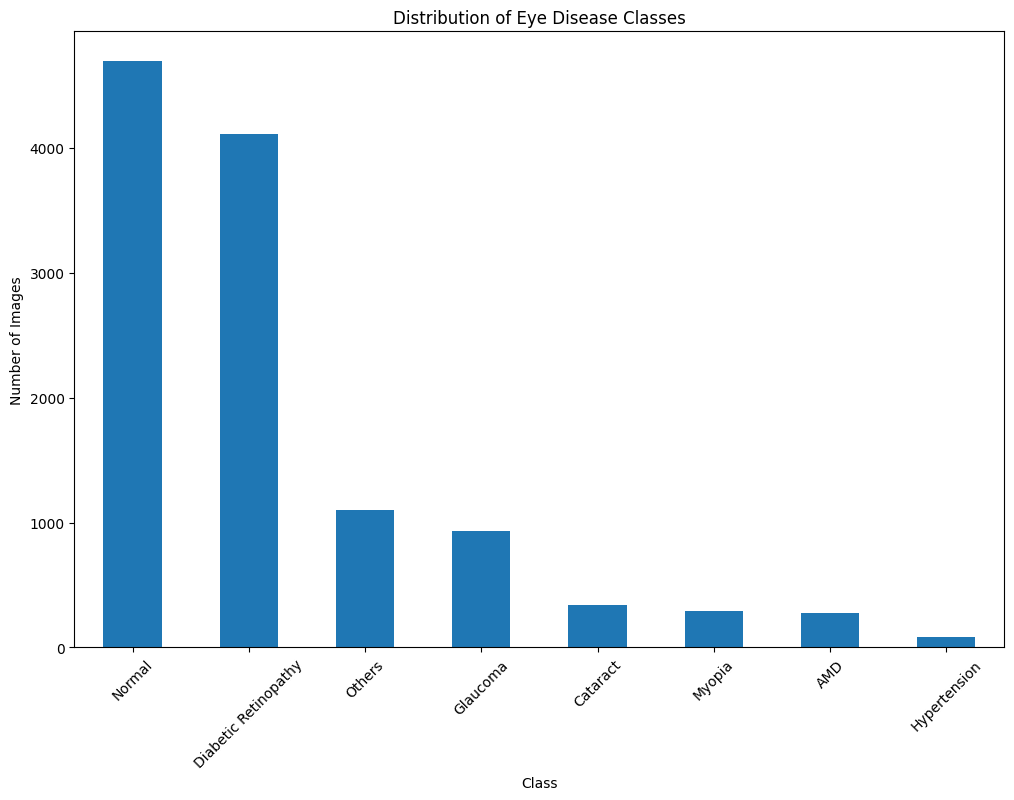

In [ ]:
import matplotlib.pyplot as plt

class_counts = metadata["unified_label"].value_counts()

plt.figure(figsize=(12, 8))
class_counts.plot(kind="bar")

plt.title("Distribution of Eye Disease Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    image_files = [
        file for file in zip_ref.namelist()
        if file.startswith("images/")
        and file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

print("Number of images found:", len(image_files))
print("First 10 images:")

for file in image_files[:10]:
    print(file)

Number of images found: 11839
First 10 images:
images/ACRIMA_Im001_ACRIMA.jpg
images/ACRIMA_Im002_ACRIMA.jpg
images/ACRIMA_Im003_ACRIMA.jpg
images/ACRIMA_Im004_ACRIMA.jpg
images/ACRIMA_Im005_ACRIMA.jpg
images/ACRIMA_Im006_ACRIMA.jpg
images/ACRIMA_Im007_ACRIMA.jpg
images/ACRIMA_Im008_ACRIMA.jpg
images/ACRIMA_Im009_ACRIMA.jpg
images/ACRIMA_Im010_ACRIMA.jpg


In [ ]:
sample_images = metadata.groupby("unified_label").first().reset_index()

display(sample_images)

,unified_label,filename,dataset,original_label
0,AMD,ODIR_48_left.jpg,ODIR5K,A
1,Cataract,ODIR_0_left.jpg,ODIR5K,C
2,Diabetic Retinopathy,APTOS_image_00001.png,APTOS2019,DR
3,Glaucoma,ACRIMA_Im310_g_ACRIMA.jpg,ACRIMA,Glaucoma
4,Hypertension,ODIR_23_left.jpg,ODIR5K,H
5,Myopia,ODIR_13_left.jpg,ODIR5K,M
6,Normal,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal
7,Others,ODIR_3_left.jpg,ODIR5K,O


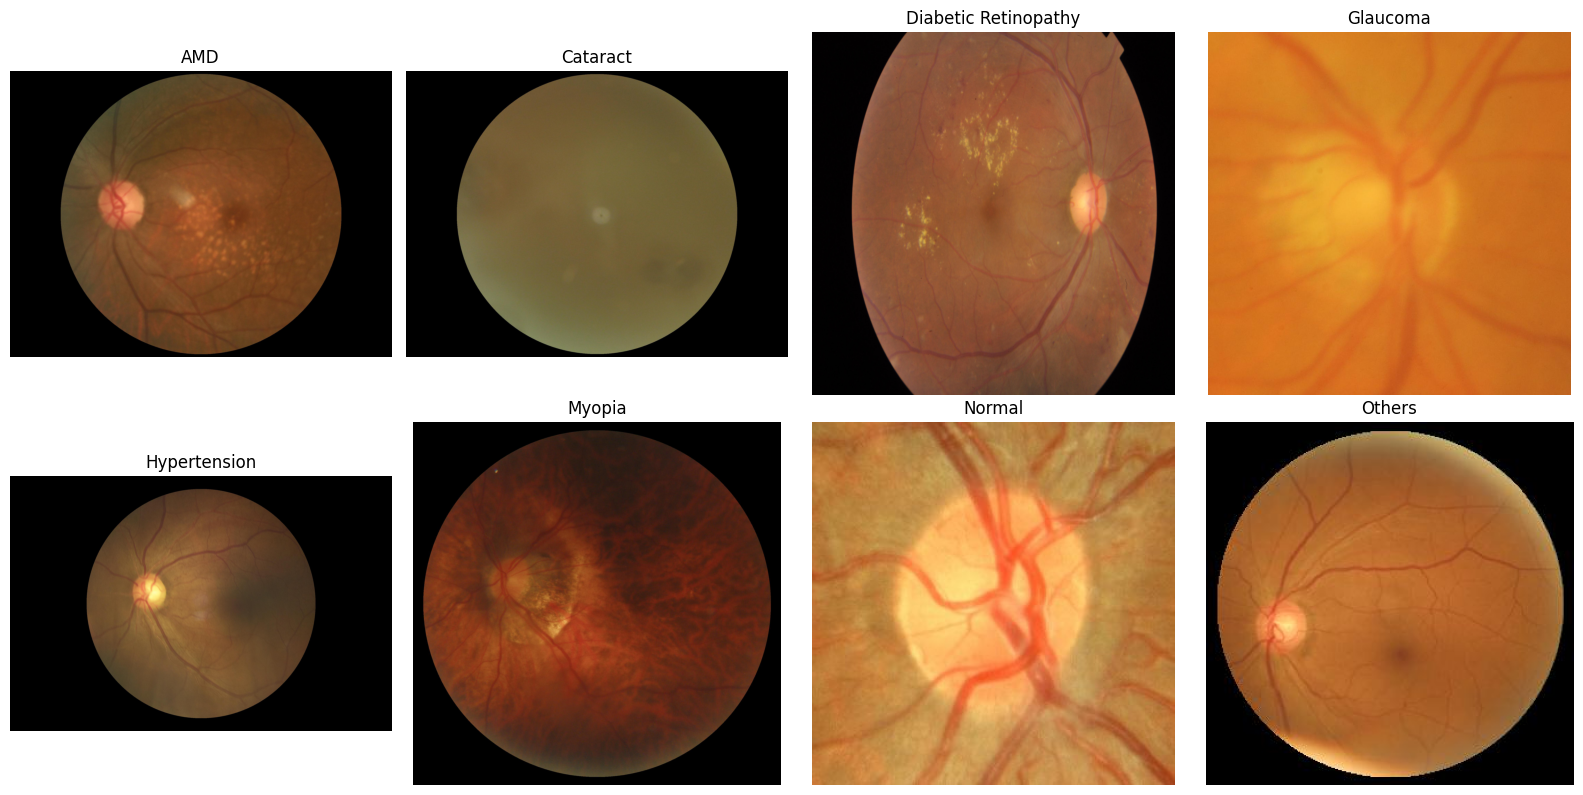

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import io

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (_, row) in zip(axes.flat, sample_images.iterrows()):

    image_path = "images/" + row["filename"]

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        image_data = zip_ref.read(image_path)

    image = Image.open(io.BytesIO(image_data))

    ax.imshow(image)
    ax.set_title(row["unified_label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Model 1: Normal vs Abnormal

normal_count = metadata[metadata["unified_label"] == "Normal"].shape[0]
abnormal_count = metadata[metadata["unified_label"] != "Normal"].shape[0]

print("Model 1")
print("Normal:", normal_count)
print("Abnormal:", abnormal_count)

Model 1
Normal: 4698
Abnormal: 7141


In [ ]:
# Model 2: 7 Abnormal Classes

abnormal_classes = metadata[metadata["unified_label"] != "Normal"]

model2_counts = abnormal_classes["unified_label"].value_counts()

print("Model 2 - Abnormal Classes")
print(model2_counts)

Model 2 - Abnormal Classes
unified_label
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        print(file)

splits/
splits/val.csv
metadata.csv
Tasks_and_Classes.md
catalog/
catalog/catalog_summary.csv
catalog/class_distribution.png
catalog/README.md
catalog/source_distribution.png
catalog/split_distribution.png
images/
images/ACRIMA_Im001_ACRIMA.jpg
images/ACRIMA_Im002_ACRIMA.jpg
images/ACRIMA_Im003_ACRIMA.jpg
images/ACRIMA_Im004_ACRIMA.jpg
images/ACRIMA_Im005_ACRIMA.jpg
images/ACRIMA_Im006_ACRIMA.jpg
images/ACRIMA_Im007_ACRIMA.jpg
images/ACRIMA_Im008_ACRIMA.jpg
images/ACRIMA_Im009_ACRIMA.jpg
images/ACRIMA_Im010_ACRIMA.jpg
images/ACRIMA_Im011_ACRIMA.jpg
images/ACRIMA_Im012_ACRIMA.jpg
images/ACRIMA_Im013_ACRIMA.jpg
images/ACRIMA_Im014_ACRIMA.jpg
images/ACRIMA_Im015_ACRIMA.jpg
images/ACRIMA_Im016_ACRIMA.jpg
images/ACRIMA_Im017_ACRIMA.jpg
images/ACRIMA_Im018_ACRIMA.jpg
images/ACRIMA_Im019_ACRIMA.jpg
images/ACRIMA_Im020_ACRIMA.jpg
images/ACRIMA_Im021_ACRIMA.jpg
images/ACRIMA_Im022_ACRIMA.jpg
images/ACRIMA_Im023_ACRIMA.jpg
images/ACRIMA_Im024_ACRIMA.jpg
images/ACRIMA_Im025_ACRIMA.jpg
images/ACRI

In [ ]:
# Check validation images

val_filenames = set(val_data["filename"])

metadata["split"] = metadata["filename"].apply(
    lambda x: "Val" if x in val_filenames else "Unknown"
)

print(metadata["split"].value_counts())

split
Unknown    10642
Val         1197
Name: count, dtype: int64


In [ ]:
print("Validation distribution:")
print(val_data["unified_label"].value_counts())

Validation distribution:
unified_label
Normal                  485
Diabetic Retinopathy    408
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64


In [ ]:
print("Total from catalog:", catalog["Total Images"].sum())
print("Train from catalog:", catalog["Train"].sum())
print("Val from catalog:", catalog["Val"].sum())
print("Test from catalog:", catalog["Test"].sum())

Total from catalog: 11839
Train from catalog: 9491
Val from catalog: 1197
Test from catalog: 1199


In [ ]:
print("Validation images:", len(val_data))
print("Unique validation images:", val_data["filename"].nunique())
print("Validation images found in metadata:",
      metadata["filename"].isin(val_data["filename"]).sum())

Validation images: 1197
Unique validation images: 1197
Validation images found in metadata: 1197


In [ ]:
remaining_data = metadata[~metadata["filename"].isin(val_data["filename"])].copy()

print("Remaining images:", len(remaining_data))
print("\nRemaining distribution:")
print(remaining_data["unified_label"].value_counts())

Remaining images: 10642

Remaining distribution:
unified_label
Normal                  4231
Diabetic Retinopathy    3687
Others                   992
Glaucoma                 837
Cataract                 306
Myopia                   264
AMD                      246
Hypertension              79
Name: count, dtype: int64


In [ ]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    for file in zip_ref.namelist():
        if file.lower().endswith((".csv", ".md", ".txt")):
            print(file)

splits/val.csv
metadata.csv
Tasks_and_Classes.md
catalog/catalog_summary.csv
catalog/README.md


In [ ]:
print(metadata["filename"].head(20).to_list())

['ACRIMA_Im001_ACRIMA.jpg', 'ACRIMA_Im002_ACRIMA.jpg', 'ACRIMA_Im003_ACRIMA.jpg', 'ACRIMA_Im004_ACRIMA.jpg', 'ACRIMA_Im005_ACRIMA.jpg', 'ACRIMA_Im006_ACRIMA.jpg', 'ACRIMA_Im007_ACRIMA.jpg', 'ACRIMA_Im008_ACRIMA.jpg', 'ACRIMA_Im009_ACRIMA.jpg', 'ACRIMA_Im010_ACRIMA.jpg', 'ACRIMA_Im011_ACRIMA.jpg', 'ACRIMA_Im012_ACRIMA.jpg', 'ACRIMA_Im013_ACRIMA.jpg', 'ACRIMA_Im014_ACRIMA.jpg', 'ACRIMA_Im015_ACRIMA.jpg', 'ACRIMA_Im016_ACRIMA.jpg', 'ACRIMA_Im017_ACRIMA.jpg', 'ACRIMA_Im018_ACRIMA.jpg', 'ACRIMA_Im019_ACRIMA.jpg', 'ACRIMA_Im020_ACRIMA.jpg']


In [ ]:
print(metadata["dataset"].value_counts())

dataset
ODIR5K       7000
APTOS2019    3484
ACRIMA        705
ORIGA         650
Name: count, dtype: int64


In [ ]:
print(val_data["dataset"].value_counts())

dataset
ODIR5K       709
APTOS2019    359
ACRIMA        70
ORIGA         59
Name: count, dtype: int64


In [ ]:
print("Total filenames:", len(metadata["filename"]))
print("Unique filenames:", metadata["filename"].nunique())

Total filenames: 11839
Unique filenames: 11839


In [ ]:
print(metadata["original_label"].value_counts())

original_label
N           2280
D           2256
DR          1857
No DR       1627
O           1102
0            482
Glaucoma     396
G            366
C            340
Normal       309
M            294
A            274
1            168
H             88
Name: count, dtype: int64


In [ ]:
print(metadata["filename"].tail(20).to_list())

['ODIR_4677_left.jpg', 'ODIR_4677_right.jpg', 'ODIR_4678_left.jpg', 'ODIR_4678_right.jpg', 'ODIR_4679_left.jpg', 'ODIR_4679_right.jpg', 'ODIR_4682_left.jpg', 'ODIR_4682_right.jpg', 'ODIR_4683_left.jpg', 'ODIR_4683_right.jpg', 'ODIR_4686_left.jpg', 'ODIR_4686_right.jpg', 'ODIR_4688_left.jpg', 'ODIR_4688_right.jpg', 'ODIR_4689_left.jpg', 'ODIR_4689_right.jpg', 'ODIR_4690_left.jpg', 'ODIR_4690_right.jpg', 'ODIR_4784_left.jpg', 'ODIR_4784_right.jpg']


In [ ]:
print(
    val_data[
        val_data["filename"].str.startswith("ODIR_")
    ]["filename"].head(20).to_list()
)

['ODIR_2634_left.jpg', 'ODIR_982_right.jpg', 'ODIR_2644_right.jpg', 'ODIR_147_right.jpg', 'ODIR_2234_left.jpg', 'ODIR_188_right.jpg', 'ODIR_2357_right.jpg', 'ODIR_94_right.jpg', 'ODIR_2903_right.jpg', 'ODIR_2947_left.jpg', 'ODIR_3968_left.jpg', 'ODIR_4603_right.jpg', 'ODIR_3302_left.jpg', 'ODIR_4591_left.jpg', 'ODIR_2955_left.jpg', 'ODIR_1262_right.jpg', 'ODIR_4079_right.jpg', 'ODIR_3954_left.jpg', 'ODIR_726_left.jpg', 'ODIR_3377_left.jpg']


In [ ]:
import re

odir_val = val_data[val_data["filename"].str.startswith("ODIR_")].copy()

odir_val["patient_id"] = odir_val["filename"].str.extract(r"ODIR_(\d+)_")

counts = odir_val["patient_id"].value_counts()

print("ODIR validation images:", len(odir_val))
print("Unique ODIR IDs:", odir_val["patient_id"].nunique())
print("IDs with both eyes in validation:", (counts == 2).sum())

print("\nIDs that appear twice:")
print(counts[counts == 2])

ODIR validation images: 709
Unique ODIR IDs: 669
IDs with both eyes in validation: 40

IDs that appear twice:
patient_id
2955    2
2486    2
2196    2
1564    2
2936    2
330     2
716     2
3363    2
1258    2
788     2
1539    2
1145    2
1092    2
463     2
518     2
486     2
2214    2
177     2
4303    2
3297    2
3165    2
2456    2
4598    2
531     2
517     2
610     2
3960    2
1548    2
2504    2
2617    2
3012    2
393     2
2559    2
657     2
2903    2
188     2
2234    2
2644    2
982     2
4591    2
Name: count, dtype: int64


In [ ]:
print(
    metadata[
        metadata["dataset"] == "APTOS2019"
    ]["filename"].head(20).to_list()
)

['APTOS_image_00001.png', 'APTOS_image_00003.png', 'APTOS_image_00007.png', 'APTOS_image_00008.png', 'APTOS_image_00012.png', 'APTOS_image_00013.png', 'APTOS_image_00015.png', 'APTOS_image_00017.png', 'APTOS_image_00022.png', 'APTOS_image_00024.png', 'APTOS_image_00025.png', 'APTOS_image_00027.png', 'APTOS_image_00030.png', 'APTOS_image_00031.png', 'APTOS_image_00034.png', 'APTOS_image_00040.png', 'APTOS_image_00042.png', 'APTOS_image_00043.png', 'APTOS_image_00046.png', 'APTOS_image_00047.png']


In [ ]:
remaining_odir = remaining_data[
    remaining_data["dataset"] == "ODIR5K"
]

print("Remaining ODIR images:", len(remaining_odir))

Remaining ODIR images: 6291


In [ ]:
remaining_odir["patient_id"] = remaining_odir["filename"].str.extract(
    r"ODIR_(\d+)_"
)

print("Remaining ODIR images:", len(remaining_odir))
print("Unique ODIR IDs:", remaining_odir["patient_id"].nunique())

Remaining ODIR images: 6291
Unique ODIR IDs: 3460


/tmp/ipykernel_2331/3036050830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remaining_odir["patient_id"] = remaining_odir["filename"].str.extract(


print(remaining_odir["patient_id"].value_counts().value_counts())

In [ ]:
acrima = remaining_data[
    remaining_data["dataset"] == "ACRIMA"
]

print("Remaining ACRIMA images:", len(acrima))
print(acrima["filename"].head(20).to_list())

Remaining ACRIMA images: 635
['ACRIMA_Im001_ACRIMA.jpg', 'ACRIMA_Im002_ACRIMA.jpg', 'ACRIMA_Im003_ACRIMA.jpg', 'ACRIMA_Im004_ACRIMA.jpg', 'ACRIMA_Im006_ACRIMA.jpg', 'ACRIMA_Im007_ACRIMA.jpg', 'ACRIMA_Im008_ACRIMA.jpg', 'ACRIMA_Im009_ACRIMA.jpg', 'ACRIMA_Im010_ACRIMA.jpg', 'ACRIMA_Im011_ACRIMA.jpg', 'ACRIMA_Im012_ACRIMA.jpg', 'ACRIMA_Im013_ACRIMA.jpg', 'ACRIMA_Im014_ACRIMA.jpg', 'ACRIMA_Im015_ACRIMA.jpg', 'ACRIMA_Im016_ACRIMA.jpg', 'ACRIMA_Im017_ACRIMA.jpg', 'ACRIMA_Im018_ACRIMA.jpg', 'ACRIMA_Im019_ACRIMA.jpg', 'ACRIMA_Im020_ACRIMA.jpg', 'ACRIMA_Im021_ACRIMA.jpg']


In [ ]:
acrima = acrima.copy()

acrima["image_id"] = acrima["filename"].str.extract(
    r"ACRIMA_Im(\d+)_"
)

print("Unique ACRIMA IDs:", acrima["image_id"].nunique())
print("Total ACRIMA images:", len(acrima))

print("\nIDs that appear more than once:")
print(acrima["image_id"].value_counts().loc[lambda x: x > 1])

Unique ACRIMA IDs: 635
Total ACRIMA images: 635

IDs that appear more than once:
Series([], Name: count, dtype: int64)


In [ ]:
origa = remaining_data[
    remaining_data["dataset"] == "ORIGA"
].copy()

print("Remaining ORIGA images:", len(origa))
print(origa["filename"].head(20).to_list())

Remaining ORIGA images: 591
['ORIGA_125.jpg', 'ORIGA_075.jpg', 'ORIGA_169.jpg', 'ORIGA_227.jpg', 'ORIGA_326.jpg', 'ORIGA_191.jpg', 'ORIGA_435.jpg', 'ORIGA_006.jpg', 'ORIGA_552.jpg', 'ORIGA_498.jpg', 'ORIGA_455.jpg', 'ORIGA_027.jpg', 'ORIGA_280.jpg', 'ORIGA_316.jpg', 'ORIGA_112.jpg', 'ORIGA_051.jpg', 'ORIGA_376.jpg', 'ORIGA_500.jpg', 'ORIGA_350.jpg', 'ORIGA_203.jpg']


In [ ]:
origa["image_id"] = origa["filename"].str.extract(
    r"ORIGA_(\d+)\."
)

print("Unique ORIGA IDs:", origa["image_id"].nunique())
print("Total ORIGA images:", len(origa))

print("\nIDs that appear more than once:")
print(origa["image_id"].value_counts().loc[lambda x: x > 1])

Unique ORIGA IDs: 591
Total ORIGA images: 591

IDs that appear more than once:
Series([], Name: count, dtype: int64)


In [ ]:
aptos = remaining_data[
    remaining_data["dataset"] == "APTOS2019"
].copy()

aptos["image_id"] = aptos["filename"].str.extract(
    r"APTOS_image_(\d+)\."
)

print("Remaining APTOS images:", len(aptos))
print("Unique APTOS IDs:", aptos["image_id"].nunique())

print("\nIDs that appear more than once:")
print(aptos["image_id"].value_counts().loc[lambda x: x > 1])

Remaining APTOS images: 3125
Unique APTOS IDs: 2617

IDs that appear more than once:
Series([], Name: count, dtype: int64)


In [ ]:
import zipfile
from PIL import Image
import io

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    for file in image_files[:10]:
        image_data = zip_ref.read(file)
        image = Image.open(io.BytesIO(image_data))

        print(file.split("/")[-1], "→", image.size)

ACRIMA_Im001_ACRIMA.jpg → (349, 349)
ACRIMA_Im002_ACRIMA.jpg → (277, 277)
ACRIMA_Im003_ACRIMA.jpg → (409, 409)
ACRIMA_Im004_ACRIMA.jpg → (406, 406)
ACRIMA_Im005_ACRIMA.jpg → (316, 316)
ACRIMA_Im006_ACRIMA.jpg → (331, 331)
ACRIMA_Im007_ACRIMA.jpg → (325, 325)
ACRIMA_Im008_ACRIMA.jpg → (409, 409)
ACRIMA_Im009_ACRIMA.jpg → (268, 268)
ACRIMA_Im010_ACRIMA.jpg → (292, 292)


In [ ]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    image_data = zip_ref.read(image_files[0])

image = Image.open(io.BytesIO(image_data)).convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)
print("Pixel range:", image.getextrema())

Image size: (349, 349)
Image mode: RGB
Pixel range: ((141, 255), (62, 228), (20, 131))


Original size: (349, 349)
After resize: (224, 224)
Array shape: (224, 224, 3)
Minimum pixel value: 0.08235294117647059
Maximum pixel value: 1.0


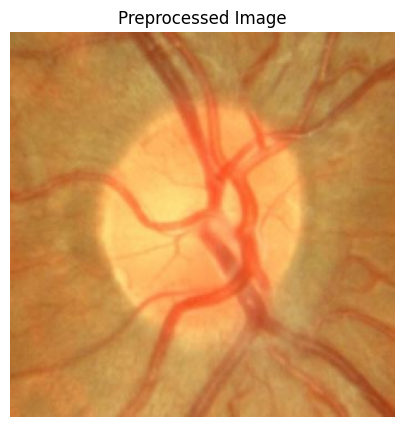

In [ ]:
import numpy as np
from PIL import Image
import io
import zipfile
import matplotlib.pyplot as plt

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    image_data = zip_ref.read(image_files[0])

image = Image.open(io.BytesIO(image_data)).convert("RGB")

# Resize
image_resized = image.resize((224, 224))

image_array = np.array(image_resized)

# Normalize
image_normalized = image_array / 255.0

print("Original size:", image.size)
print("After resize:", image_resized.size)
print("Array shape:", image_normalized.shape)
print("Minimum pixel value:", image_normalized.min())
print("Maximum pixel value:", image_normalized.max())

plt.figure(figsize=(5, 5))
plt.imshow(image_normalized)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

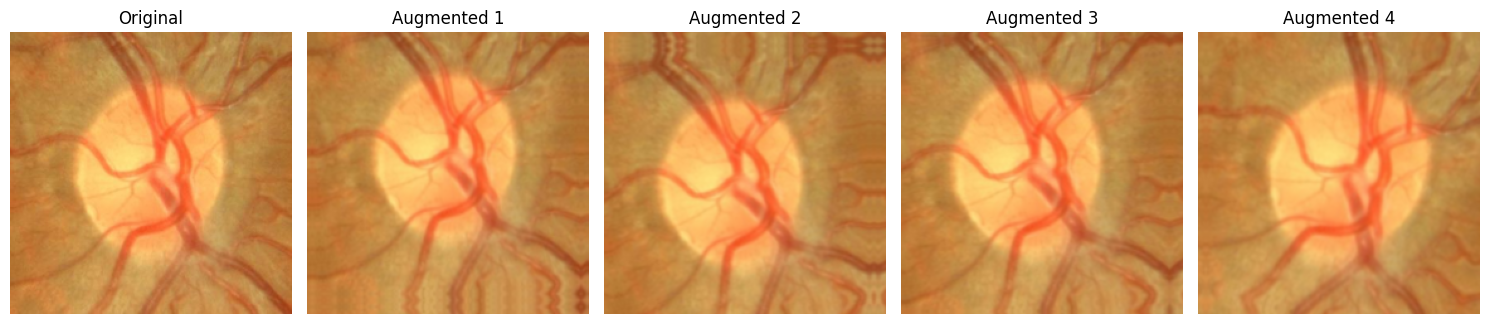

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

# Convert the preprocessed image to TensorFlow tensor
image_tensor = tf.convert_to_tensor(image_normalized, dtype=tf.float32)

# Add batch dimension
image_tensor = tf.expand_dims(image_tensor, axis=0)

# Generate augmented versions
augmented_images = [
    data_augmentation(image_tensor, training=True)
    for _ in range(4)
]

# Display original + augmented images
plt.figure(figsize=(15, 6))

plt.subplot(1, 5, 1)
plt.imshow(image_normalized)
plt.title("Original")
plt.axis("off")

for i in range(4):
    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_images[i][0])
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import re

# Copy the metadata
remaining_df = metadata.copy()

# Remove the official validation set
remaining_df = remaining_df[
    ~remaining_df["filename"].isin(val_df["filename"])
].reset_index(drop=True)

print("Remaining images:", len(remaining_df))

# Create groups
# For ODIR5K:
# left and right eye images of the same person will belong to the same group.
# For other datasets, each image is treated as its own group.
def create_group(row):
    filename = row["filename"]
    dataset = row["dataset"]

    if dataset == "ODIR5K":
        match = re.search(r"ODIR_(\d+)_", filename)
        if match:
            return f"ODIR_{match.group(1)}"

    # Unique group for other datasets
    return filename


remaining_df["group"] = remaining_df.apply(create_group, axis=1)

print("Unique groups:", remaining_df["group"].nunique())

# Stratified Group Split
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = remaining_df["filename"]
y = remaining_df["unified_label"]
groups = remaining_df["group"]

# Take the first fold as Test
train_idx, test_idx = next(
    sgkf.split(X, y, groups)
)

train_df = remaining_df.iloc[train_idx].copy()
test_df = remaining_df.iloc[test_idx].copy()

print("\nTrain images:", len(train_df))
print("Test images:", len(test_df))

print("\nTrain class distribution:")
print(train_df["unified_label"].value_counts())

print("\nTest class distribution:")
print(test_df["unified_label"].value_counts())

NameError: name 'val_df' is not defined

In [ ]:
import zipfile
import pandas as pd

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open("splits/val.csv") as f:
        val_df = pd.read_csv(f)

print("Validation images:", len(val_df))
print("\nValidation class distribution:")
print(val_df["unified_label"].value_counts())

Validation images: 1197

Validation class distribution:
unified_label
Normal                  485
Diabetic Retinopathy    408
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import re

# Copy the metadata
remaining_df = metadata.copy()

# Remove the official validation set
remaining_df = remaining_df[
    ~remaining_df["filename"].isin(val_df["filename"])
].reset_index(drop=True)

print("Remaining images:", len(remaining_df))

# Create groups
# For ODIR5K:
# left and right eye images of the same person will belong to the same group.
# For other datasets, each image is treated as its own group.
def create_group(row):
    filename = row["filename"]
    dataset = row["dataset"]

    if dataset == "ODIR5K":
        match = re.search(r"ODIR_(\d+)_", filename)
        if match:
            return f"ODIR_{match.group(1)}"

    # Unique group for other datasets
    return filename


remaining_df["group"] = remaining_df.apply(create_group, axis=1)

print("Unique groups:", remaining_df["group"].nunique())

# Stratified Group Split
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = remaining_df["filename"]
y = remaining_df["unified_label"]
groups = remaining_df["group"]

# Take the first fold as Test
train_idx, test_idx = next(
    sgkf.split(X, y, groups)
)

train_df = remaining_df.iloc[train_idx].copy()
test_df = remaining_df.iloc[test_idx].copy()

print("\nTrain images:", len(train_df))
print("Test images:", len(test_df))

print("\nTrain class distribution:")
print(train_df["unified_label"].value_counts())

print("\nTest class distribution:")
print(test_df["unified_label"].value_counts())

Remaining images: 10642
Unique groups: 7811

Train images: 8509
Test images: 2133

Train class distribution:
unified_label
Normal                  3373
Diabetic Retinopathy    2958
Others                   806
Glaucoma                 654
Cataract                 241
Myopia                   220
AMD                      196
Hypertension              61
Name: count, dtype: int64

Test class distribution:
unified_label
Normal                  858
Diabetic Retinopathy    729
Others                  186
Glaucoma                183
Cataract                 65
AMD                      50
Myopia                   44
Hypertension             18
Name: count, dtype: int64


In [ ]:
# Check group overlap between Train, Validation, and Test

train_groups = set(train_df["group"])
test_groups = set(test_df["group"])

# Create groups for validation
val_check = val_df.copy()
val_check["group"] = val_check.apply(create_group, axis=1)
val_groups = set(val_check["group"])

print("Train ↔ Test overlap:", len(train_groups & test_groups))
print("Train ↔ Validation overlap:", len(train_groups & val_groups))
print("Test ↔ Validation overlap:", len(test_groups & val_groups))

Train ↔ Test overlap: 0
Train ↔ Validation overlap: 508
Test ↔ Validation overlap: 121


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import re

# 1. Start from the full metadata
remaining_df = metadata.copy()

# 2. Remove the official validation images
remaining_df = remaining_df[
    ~remaining_df["filename"].isin(val_df["filename"])
].reset_index(drop=True)

# 3. Create groups
def create_group(row):
    filename = row["filename"]
    dataset = row["dataset"]

    if dataset == "ODIR5K":
        match = re.search(r"ODIR_(\d+)_", filename)
        if match:
            return f"ODIR_{match.group(1)}"

    # For other datasets, each image is its own group
    return filename


remaining_df["group"] = remaining_df.apply(create_group, axis=1)

# 4. Create groups for validation
val_check = val_df.copy()
val_check["group"] = val_check.apply(create_group, axis=1)

# Groups already used by Validation
val_groups = set(val_check["group"])

print("Validation groups:", len(val_groups))

# 5. Remove ALL groups that already appear in Validation
remaining_df = remaining_df[
    ~remaining_df["group"].isin(val_groups)
].reset_index(drop=True)

print("Images available for Train/Test:", len(remaining_df))
print("Groups available for Train/Test:", remaining_df["group"].nunique())

# 6. Stratified Group Split
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = remaining_df["filename"]
y = remaining_df["unified_label"]
groups = remaining_df["group"]

train_idx, test_idx = next(
    sgkf.split(X, y, groups)
)

train_df = remaining_df.iloc[train_idx].copy()
test_df = remaining_df.iloc[test_idx].copy()

# 7. Results
print("\nTrain images:", len(train_df))
print("Test images:", len(test_df))

print("\nTrain class distribution:")
print(train_df["unified_label"].value_counts())

print("\nTest class distribution:")
print(test_df["unified_label"].value_counts())

Validation groups: 1157
Images available for Train/Test: 10013
Groups available for Train/Test: 7182

Train images: 8013
Test images: 2000

Train class distribution:
unified_label
Normal                  3257
Diabetic Retinopathy    2775
Others                   694
Glaucoma                 629
Cataract                 228
AMD                      190
Myopia                   188
Hypertension              52
Name: count, dtype: int64

Test class distribution:
unified_label
Normal                  773
Diabetic Retinopathy    701
Others                  206
Glaucoma                168
Myopia                   52
Cataract                 50
AMD                      32
Hypertension             18
Name: count, dtype: int64


In [ ]:
train_groups = set(train_df["group"])
test_groups = set(test_df["group"])
val_groups = set(val_check["group"])

print("Train ↔ Test overlap:", len(train_groups & test_groups))
print("Train ↔ Validation overlap:", len(train_groups & val_groups))
print("Test ↔ Validation overlap:", len(test_groups & val_groups))

Train ↔ Test overlap: 0
Train ↔ Validation overlap: 0
Test ↔ Validation overlap: 0


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile
import pandas as pd

zip_path = '/content/drive/MyDrive/EyeDiseaseDataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('metadata.csv') as f:
        metadata = pd.read_csv(f)

print("Metadata shape:", metadata.shape)
print("\nColumns:")
print(metadata.columns.tolist())

print("\nClass distribution:")
print(metadata["unified_label"].value_counts())

Metadata shape: (11839, 4)

Columns:
['filename', 'dataset', 'unified_label', 'original_label']

Class distribution:
unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('splits/val.csv') as f:
        val_df = pd.read_csv(f)

print("Validation images:", len(val_df))

print("\nValidation class distribution:")
print(val_df["unified_label"].value_counts())

Validation images: 1197

Validation class distribution:
unified_label
Normal                  485
Diabetic Retinopathy    408
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import re

# Start from the full metadata
remaining_df = metadata.copy()

# Remove official validation images
remaining_df = remaining_df[
    ~remaining_df["filename"].isin(val_df["filename"])
].reset_index(drop=True)

# Create groups
def create_group(row):
    filename = row["filename"]
    dataset = row["dataset"]

    if dataset == "ODIR5K":
        match = re.search(r"ODIR_(\d+)_", filename)
        if match:
            return f"ODIR_{match.group(1)}"

    # For other datasets, each image is its own group
    return filename


remaining_df["group"] = remaining_df.apply(create_group, axis=1)

# Create groups for validation
val_check = val_df.copy()
val_check["group"] = val_check.apply(create_group, axis=1)

# Groups already present in validation
val_groups = set(val_check["group"])

print("Validation groups:", len(val_groups))

# Remove all groups already represented in validation
remaining_df = remaining_df[
    ~remaining_df["group"].isin(val_groups)
].reset_index(drop=True)

print("Images available for Train/Test:", len(remaining_df))
print("Groups available for Train/Test:", remaining_df["group"].nunique())

# Stratified Group Split
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = remaining_df["filename"]
y = remaining_df["unified_label"]
groups = remaining_df["group"]

train_idx, test_idx = next(
    sgkf.split(X, y, groups)
)

train_df = remaining_df.iloc[train_idx].copy()
test_df = remaining_df.iloc[test_idx].copy()

print("\nTrain images:", len(train_df))
print("Test images:", len(test_df))

print("\nTrain class distribution:")
print(train_df["unified_label"].value_counts())

print("\nTest class distribution:")
print(test_df["unified_label"].value_counts())

Validation groups: 1157
Images available for Train/Test: 10013
Groups available for Train/Test: 7182

Train images: 8013
Test images: 2000

Train class distribution:
unified_label
Normal                  3257
Diabetic Retinopathy    2775
Others                   694
Glaucoma                 629
Cataract                 228
AMD                      190
Myopia                   188
Hypertension              52
Name: count, dtype: int64

Test class distribution:
unified_label
Normal                  773
Diabetic Retinopathy    701
Others                  206
Glaucoma                168
Myopia                   52
Cataract                 50
AMD                      32
Hypertension             18
Name: count, dtype: int64


In [ ]:
train_groups = set(train_df["group"])
test_groups = set(test_df["group"])
val_groups = set(val_check["group"])

print("Train ↔ Test overlap:", len(train_groups & test_groups))
print("Train ↔ Validation overlap:", len(train_groups & val_groups))
print("Test ↔ Validation overlap:", len(test_groups & val_groups))

Train ↔ Test overlap: 0
Train ↔ Validation overlap: 0
Test ↔ Validation overlap: 0


Sample filename: ACRIMA_Im001_ACRIMA.jpg
Image size: (224, 224)
Array shape: (224, 224, 3)
Data type: uint8


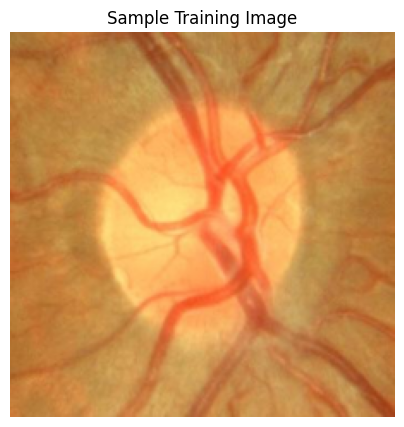

In [ ]:
import tensorflow as tf
import zipfile
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# Take one image from the training set
sample_filename = train_df.iloc[0]["filename"]

print("Sample filename:", sample_filename)

# Read the image from the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    image_data = zip_ref.read("images/" + sample_filename)

# Open image
image = Image.open(io.BytesIO(image_data)).convert("RGB")

# Resize
image = image.resize((224, 224))

# Convert to NumPy array
image_array = np.array(image)

print("Image size:", image.size)
print("Array shape:", image_array.shape)
print("Data type:", image_array.dtype)

# Display
plt.figure(figsize=(5, 5))
plt.imshow(image_array)
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

In [ ]:
import shutil

total, used, free = shutil.disk_usage("/content")

print(f"Total disk space: {total / (1024**3):.2f} GB")
print(f"Used disk space:  {used / (1024**3):.2f} GB")
print(f"Free disk space:  {free / (1024**3):.2f} GB")

Total disk space: 112.64 GB
Used disk space:  47.39 GB
Free disk space:  65.23 GB


In [ ]:
import zipfile
import os

extract_dir = "/content/eye_dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    image_files_in_zip = [
        file for file in zip_ref.namelist()
        if file.startswith("images/")
        and file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Images to extract:", len(image_files_in_zip))

    for i, file in enumerate(image_files_in_zip):
        zip_ref.extract(file, extract_dir)

        if (i + 1) % 1000 == 0:
            print(f"Extracted: {i + 1}/{len(image_files_in_zip)}")

print("\nExtraction completed.")

Images to extract: 11839
Extracted: 1000/11839
Extracted: 2000/11839
Extracted: 3000/11839
Extracted: 4000/11839
Extracted: 5000/11839
Extracted: 6000/11839
Extracted: 7000/11839
Extracted: 8000/11839
Extracted: 9000/11839
Extracted: 10000/11839
Extracted: 11000/11839

Extraction completed.


In [ ]:
import os

images_dir = "/content/eye_dataset/images"

image_files = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Images found:", len(image_files))
print("First 5 images:")
for file in image_files[:5]:
    print(file)

Images found: 11839
First 5 images:
ODIR_4670_left.jpg
ODIR_2760_right.jpg
ACRIMA_Im527_g_ACRIMA.jpg
ODIR_2535_left.jpg
APTOS_image_00515.png


In [ ]:
# Label mapping for the 8-class problem

class_names = [
    "Normal",
    "Diabetic Retinopathy",
    "Others",
    "Glaucoma",
    "Cataract",
    "Myopia",
    "AMD",
    "Hypertension"
]

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Class to index:")
print(class_to_index)

print("\nIndex to class:")
print(index_to_class)

Class to index:
{'Normal': 0, 'Diabetic Retinopathy': 1, 'Others': 2, 'Glaucoma': 3, 'Cataract': 4, 'Myopia': 5, 'AMD': 6, 'Hypertension': 7}

Index to class:
{0: 'Normal', 1: 'Diabetic Retinopathy', 2: 'Others', 3: 'Glaucoma', 4: 'Cataract', 5: 'Myopia', 6: 'AMD', 7: 'Hypertension'}


In [ ]:
import tensorflow as tf
import os

IMG_SIZE = (224, 224)

# Take 5 training samples
sample_df = train_df.head(5).copy()

def get_image_path(filename):
    return os.path.join("/content/eye_dataset/images", filename)

for _, row in sample_df.iterrows():
    image_path = get_image_path(row["filename"])

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG/PNG automatically
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Convert pixels from 0-255 to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    label = class_to_index[row["unified_label"]]

    print(
        "Image:",
        row["filename"],
        "| Shape:",
        image.shape,
        "| Label:",
        label,
        "| Class:",
        row["unified_label"]
    )

Image: ACRIMA_Im001_ACRIMA.jpg | Shape: (224, 224, 3) | Label: 0 | Class: Normal
Image: ACRIMA_Im002_ACRIMA.jpg | Shape: (224, 224, 3) | Label: 0 | Class: Normal
Image: ACRIMA_Im003_ACRIMA.jpg | Shape: (224, 224, 3) | Label: 0 | Class: Normal
Image: ACRIMA_Im006_ACRIMA.jpg | Shape: (224, 224, 3) | Label: 0 | Class: Normal
Image: ACRIMA_Im007_ACRIMA.jpg | Shape: (224, 224, 3) | Label: 0 | Class: Normal


In [ ]:
import tensorflow as tf
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

images_dir = "/content/eye_dataset/images"


def load_image(filename, label):
    # Build full image path
    image_path = tf.strings.join([images_dir, "/", filename])

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG/PNG
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Convert to float and normalize
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


# Convert filenames to full arrays
train_filenames = train_df["filename"].values

train_labels = train_df["unified_label"].map(class_to_index).values


# Create TensorFlow Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_filenames, train_labels)
)

# Shuffle
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=42
)

# Load and preprocess images
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch
train_dataset = train_dataset.batch(BATCH_SIZE)

# Prefetch
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


print("Training dataset created successfully.")

Training dataset created successfully.


In [ ]:
# Test one batch from the training dataset

for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Images data type:", images.dtype)
    print("Labels data type:", labels.dtype)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images data type: <dtype: 'float32'>
Labels data type: <dtype: 'int64'>
Pixel minimum: 0.0
Pixel maximum: 1.0


In [ ]:
# Create Validation and Test datasets

val_filenames = val_df["filename"].values
val_labels = val_df["unified_label"].map(class_to_index).values

test_filenames = test_df["filename"].values
test_labels = test_df["unified_label"].map(class_to_index).values


# Validation Dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_filenames, val_labels)
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


# Test Dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_filenames, test_labels)
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)


print("Validation dataset created successfully.")
print("Test dataset created successfully.")

Validation dataset created successfully.
Test dataset created successfully.


In [ ]:
# Check one batch from Validation and Test datasets

print("VALIDATION BATCH")
for images, labels in val_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Data type:", images.dtype)
    print("Pixel range:",
          tf.reduce_min(images).numpy(),
          "to",
          tf.reduce_max(images).numpy())

print("\nTEST BATCH")
for images, labels in test_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Data type:", images.dtype)
    print("Pixel range:",
          tf.reduce_min(images).numpy(),
          "to",
          tf.reduce_max(images).numpy())

VALIDATION BATCH
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Data type: <dtype: 'float32'>
Pixel range: 0.0 to 1.0

TEST BATCH
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Data type: <dtype: 'float32'>
Pixel range: 0.0 to 1.0


In [ ]:
# Create binary labels for Model 1
# 0 = Normal
# 1 = Abnormal

def create_model1_labels(df):
    return (
        df["unified_label"]
        .map(lambda x: 0 if x == "Normal" else 1)
        .values
    )


train_model1_labels = create_model1_labels(train_df)
val_model1_labels = create_model1_labels(val_df)
test_model1_labels = create_model1_labels(test_df)


print("Model 1 labels created successfully.")

print("\nTraining:")
print("Normal:", (train_model1_labels == 0).sum())
print("Abnormal:", (train_model1_labels == 1).sum())

print("\nValidation:")
print("Normal:", (val_model1_labels == 0).sum())
print("Abnormal:", (val_model1_labels == 1).sum())

print("\nTest:")
print("Normal:", (test_model1_labels == 0).sum())
print("Abnormal:", (test_model1_labels == 1).sum())

Model 1 labels created successfully.

Training:
Normal: 3257
Abnormal: 4756

Validation:
Normal: 485
Abnormal: 712

Test:
Normal: 773
Abnormal: 1227


In [ ]:
# Create Model 1 datasets
# 0 = Normal
# 1 = Abnormal

train_model1_dataset = tf.data.Dataset.from_tensor_slices(
    (train_filenames, train_model1_labels)
)

train_model1_dataset = train_model1_dataset.shuffle(
    buffer_size=len(train_model1_labels),
    seed=42
)

train_model1_dataset = train_model1_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_model1_dataset = train_model1_dataset.batch(BATCH_SIZE)
train_model1_dataset = train_model1_dataset.prefetch(tf.data.AUTOTUNE)


val_model1_dataset = tf.data.Dataset.from_tensor_slices(
    (val_filenames, val_model1_labels)
)

val_model1_dataset = val_model1_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_model1_dataset = val_model1_dataset.batch(BATCH_SIZE)
val_model1_dataset = val_model1_dataset.prefetch(tf.data.AUTOTUNE)


test_model1_dataset = tf.data.Dataset.from_tensor_slices(
    (test_filenames, test_model1_labels)
)

test_model1_dataset = test_model1_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_model1_dataset = test_model1_dataset.batch(BATCH_SIZE)
test_model1_dataset = test_model1_dataset.prefetch(tf.data.AUTOTUNE)


print("Model 1 datasets created successfully.")

Model 1 datasets created successfully.


In [ ]:
# Check one batch from Model 1

for images, labels in train_model1_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Images dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)
    print("Pixel range:",
          tf.reduce_min(images).numpy(),
          "to",
          tf.reduce_max(images).numpy())
    print("Unique labels:", tf.unique(labels).y.numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int64'>
Pixel range: 0.0 to 1.0
Unique labels: [0 1]


In [ ]:
from tensorflow.keras import layers, models

model1_cnn = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification part
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])


model1_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05)
], name="data_augmentation")


# Add augmentation to the beginning of Model 1
model1_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])


model1_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

print("Model 1 compiled successfully.")

Model 1 compiled successfully.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

model1_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_model1_labels
)

model1_class_weights = {
    0: model1_class_weights[0],
    1: model1_class_weights[1]
}

print("Model 1 class weights:")
print(model1_class_weights)

Model 1 class weights:
{0: np.float64(1.2301197420939516), 1: np.float64(0.8424095878889823)}


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_model1 = model1_cnn.fit(
    train_model1_dataset,
    validation_data=val_model1_dataset,
    epochs=10,
    class_weight=model1_class_weights,
    callbacks=[early_stopping]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 137s 500ms/step - accuracy: 0.5733 - loss: 0.6805 - val_accuracy: 0.6683 - val_loss: 0.6567
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 474ms/step - accuracy: 0.6162 - loss: 0.6591 - val_accuracy: 0.6591 - val_loss: 0.6320
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 116s 462ms/step - accuracy: 0.6291 - loss: 0.6304 - val_accuracy: 0.6617 - val_loss: 0.6036
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 122s 485ms/step - accuracy: 0.6644 - loss: 0.5987 - val_accuracy: 0.6876 - val_loss: 0.6154
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 116s 463ms/step - accuracy: 0.6752 - loss: 0.5805 - val_accuracy: 0.7034 - val_loss: 0.6045
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 116s 463ms/step - accuracy: 0.6909 - loss: 0.5744 - val_accuracy: 0.6867 - val_loss: 0.6244


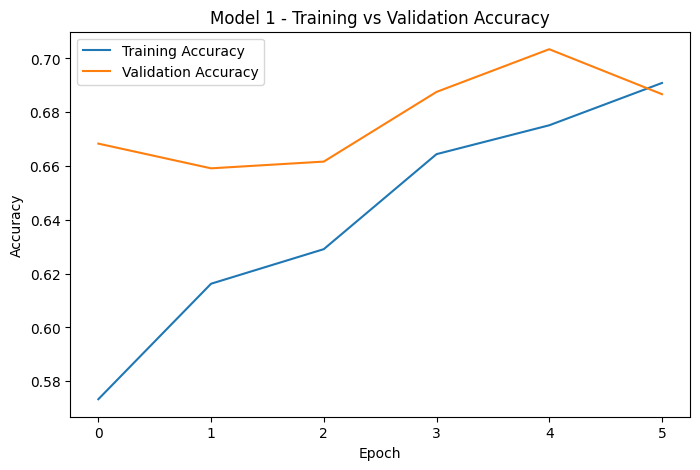

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_model1.history["accuracy"], label="Training Accuracy")
plt.plot(history_model1.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 1 - Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
# Evaluate Model 1 on the Test Set

test_loss, test_accuracy = model1_cnn.evaluate(
    test_model1_dataset,
    verbose=1
)

print("\nModel 1 Test Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 479ms/step - accuracy: 0.6800 - loss: 0.5711

Model 1 Test Results
Test Loss: 0.5710922479629517
Test Accuracy: 0.6800000071525574


In [ ]:
import numpy as np

# Get predictions from Model 1
y_true_model1 = []
y_pred_model1 = []

for images, labels in test_model1_dataset:
    predictions = model1_cnn.predict(images, verbose=0)

    y_true_model1.extend(labels.numpy())
    y_pred_model1.extend((predictions >= 0.5).astype(int).flatten())

y_true_model1 = np.array(y_true_model1)
y_pred_model1 = np.array(y_pred_model1)

print("Predictions generated successfully.")
print("Number of test samples:", len(y_true_model1))
print("Unique true labels:", np.unique(y_true_model1))
print("Unique predicted labels:", np.unique(y_pred_model1))

Predictions generated successfully.
Number of test samples: 2000
Unique true labels: [0 1]
Unique predicted labels: [0 1]


Confusion Matrix:
[[375 398]
 [242 985]]


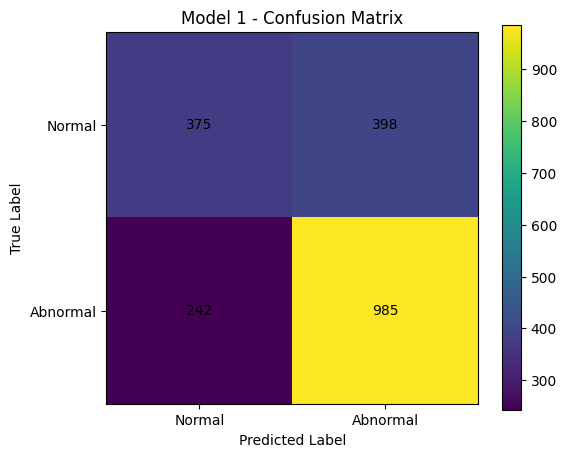

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_model1 = confusion_matrix(
    y_true_model1,
    y_pred_model1
)

print("Confusion Matrix:")
print(cm_model1)


plt.figure(figsize=(6, 5))

plt.imshow(cm_model1)

plt.title("Model 1 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_model1[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true_model1, y_pred_model1)

precision = precision_score(
    y_true_model1,
    y_pred_model1,
    pos_label=1
)

recall = recall_score(
    y_true_model1,
    y_pred_model1,
    pos_label=1
)

f1 = f1_score(
    y_true_model1,
    y_pred_model1,
    pos_label=1
)

print("Model 1 Metrics")
print("----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(
    classification_report(
        y_true_model1,
        y_pred_model1,
        target_names=["Normal", "Abnormal"]
    )
)

Model 1 Metrics
----------------
Accuracy : 0.68
Precision: 0.7122198120028923
Recall   : 0.8027709861450693
F1-score : 0.7547892720306514

Classification Report:
              precision    recall  f1-score   support

      Normal       0.61      0.49      0.54       773
    Abnormal       0.71      0.80      0.75      1227

    accuracy                           0.68      2000
   macro avg       0.66      0.64      0.65      2000
weighted avg       0.67      0.68      0.67      2000



In [ ]:
print("metadata" in globals())
print("train_df" in globals())
print("test_df" in globals())
print("images_dir" in globals())

True
True
True
True


In [ ]:
# Model 2: keep only abnormal classes

abnormal_classes = [
    "Diabetic Retinopathy",
    "Others",
    "Glaucoma",
    "Cataract",
    "Myopia",
    "AMD",
    "Hypertension"
]

model2_class_to_index = {
    "Diabetic Retinopathy": 0,
    "Others": 1,
    "Glaucoma": 2,
    "Cataract": 3,
    "Myopia": 4,
    "AMD": 5,
    "Hypertension": 6
}

model2_index_to_class = {
    v: k for k, v in model2_class_to_index.items()
}


# Keep only abnormal classes
train_model2_df = train_df[
    train_df["unified_label"].isin(abnormal_classes)
].copy()

val_model2_df = val_df[
    val_df["unified_label"].isin(abnormal_classes)
].copy()

test_model2_df = test_df[
    test_df["unified_label"].isin(abnormal_classes)
].copy()


print("Model 2 class distribution")

print("\nTraining:")
print(train_model2_df["unified_label"].value_counts())

print("\nValidation:")
print(val_model2_df["unified_label"].value_counts())

print("\nTest:")
print(test_model2_df["unified_label"].value_counts())

Model 2 class distribution

Training:
unified_label
Diabetic Retinopathy    2775
Others                   694
Glaucoma                 629
Cataract                 228
AMD                      190
Myopia                   188
Hypertension              52
Name: count, dtype: int64

Validation:
unified_label
Diabetic Retinopathy    408
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      28
Hypertension              9
Name: count, dtype: int64

Test:
unified_label
Diabetic Retinopathy    701
Others                  206
Glaucoma                168
Myopia                   52
Cataract                 50
AMD                      32
Hypertension             18
Name: count, dtype: int64


In [ ]:
# Create labels for Model 2

train_model2_labels = (
    train_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)

val_model2_labels = (
    val_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)

test_model2_labels = (
    test_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)


print("Model 2 labels created successfully.")

print("\nTraining labels:")
print(np.unique(train_model2_labels, return_counts=True))

print("\nValidation labels:")
print(np.unique(val_model2_labels, return_counts=True))

print("\nTest labels:")
print(np.unique(test_model2_labels, return_counts=True))

Model 2 labels created successfully.

Training labels:
(array([0, 1, 2, 3, 4, 5, 6]), array([2775,  694,  629,  228,  188,  190,   52]))

Validation labels:
(array([0, 1, 2, 3, 4, 5, 6]), array([408, 110,  93,  34,  30,  28,   9]))

Test labels:
(array([0, 1, 2, 3, 4, 5, 6]), array([701, 206, 168,  50,  52,  32,  18]))


In [ ]:
# Create TensorFlow datasets for Model 2

def create_model2_dataset(df, labels, shuffle=False):
    filenames = df["filename"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filenames, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_model2_dataset = create_model2_dataset(
    train_model2_df,
    train_model2_labels,
    shuffle=True
)

val_model2_dataset = create_model2_dataset(
    val_model2_df,
    val_model2_labels,
    shuffle=False
)

test_model2_dataset = create_model2_dataset(
    test_model2_df,
    test_model2_labels,
    shuffle=False
)

print("Model 2 datasets created successfully.")

Model 2 datasets created successfully.


In [ ]:
# Check one batch from Model 2

for images, labels in train_model2_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Images dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())
    print("Unique labels:", np.unique(labels.numpy()))

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Images dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int64'>
Pixel range: 0.0 to 1.0
Unique labels: [0 1 2 3 5]


In [ ]:
# Check all labels in the Model 2 training dataset

all_model2_labels = []

for _, labels in train_model2_dataset:
    all_model2_labels.extend(labels.numpy())

all_model2_labels = np.array(all_model2_labels)

print("All unique labels:", np.unique(all_model2_labels))
print("\nLabel counts:")

for label in range(7):
    print(
        label,
        "->",
        model2_index_to_class[label],
        ":",
        np.sum(all_model2_labels == label)
    )

All unique labels: [0 1 2 3 4 5 6]

Label counts:
0 -> Diabetic Retinopathy : 2775
1 -> Others : 694
2 -> Glaucoma : 629
3 -> Cataract : 228
4 -> Myopia : 188
5 -> AMD : 190
6 -> Hypertension : 52


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(7)

model2_class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_model2_labels
)

model2_class_weights = {
    i: model2_class_weights_values[i]
    for i in classes
}

print("Model 2 Class Weights:\n")

for i in classes:
    print(
        i,
        "->",
        model2_index_to_class[i],
        ":",
        round(model2_class_weights[i], 3)
    )

Model 2 Class Weights:

0 -> Diabetic Retinopathy : 0.245
1 -> Others : 0.979
2 -> Glaucoma : 1.08
3 -> Cataract : 2.98
4 -> Myopia : 3.614
5 -> AMD : 3.576
6 -> Hypertension : 13.066


In [ ]:
from tensorflow.keras import layers, models

model2_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Feature extraction
    layers.GlobalAveragePooling2D(),

    # Classification
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 7 abnormal classes
    layers.Dense(7, activation="softmax")
])

model2_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model 2 compiled successfully!")

Model 2 compiled successfully!


In [ ]:
early_stopping_model2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_model2 = model2_cnn.fit(
    train_model2_dataset,
    validation_data=val_model2_dataset,
    epochs=10,
    class_weight=model2_class_weights,
    callbacks=[early_stopping_model2]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 77s 482ms/step - accuracy: 0.1299 - loss: 1.8827 - val_accuracy: 0.1854 - val_loss: 1.8581
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 480ms/step - accuracy: 0.2307 - loss: 1.7516 - val_accuracy: 0.1980 - val_loss: 1.8398
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 547ms/step - accuracy: 0.2508 - loss: 1.7068 - val_accuracy: 0.1334 - val_loss: 1.7791
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 545ms/step - accuracy: 0.2704 - loss: 1.6740 - val_accuracy: 0.2711 - val_loss: 1.7577
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 478ms/step - accuracy: 0.2836 - loss: 1.6455 - val_accuracy: 0.1447 - val_loss: 1.8031
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 80s 467ms/step - accuracy: 0.2611 - loss: 1.6439 - val_accuracy: 0.1756 - val_loss: 1.7523
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 480ms/step - accuracy: 0.2969 - loss: 1.6361 - val_accuracy: 0.2767 - val_loss: 1.7407
Epoch 8/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 475ms/step - accuracy: 0.3103 - loss: 1

In [ ]:
test_loss_model2, test_accuracy_model2 = model2_cnn.evaluate(
    test_model2_dataset,
    verbose=1
)

print("\nModel 2 Test Results")
print("-------------------")
print("Test Loss:", round(test_loss_model2, 4))
print("Test Accuracy:", round(test_accuracy_model2, 4))

39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 594ms/step - accuracy: 0.2983 - loss: 1.6841

Model 2 Test Results
-------------------
Test Loss: 1.6841
Test Accuracy: 0.2983


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
import numpy as np

# Get predictions
y_true_model2 = []
y_pred_model2 = []

for images, labels in test_model2_dataset:
    predictions = model2_cnn.predict(images, verbose=0)

    y_true_model2.extend(labels.numpy())
    y_pred_model2.extend(np.argmax(predictions, axis=1))

y_true_model2 = np.array(y_true_model2)
y_pred_model2 = np.array(y_pred_model2)

# Classification report
print("Model 2 Classification Report")
print("=============================\n")

print(
    classification_report(
        y_true_model2,
        y_pred_model2,
        labels=np.arange(7),
        target_names=abnormal_classes,
        digits=4,
        zero_division=0
    )
)

Model 2 Classification Report

                      precision    recall  f1-score   support

Diabetic Retinopathy     0.9264    0.2154    0.3495       701
              Others     0.2237    0.3204    0.2635       206
            Glaucoma     0.8947    0.6071    0.7234       168
            Cataract     0.1319    0.4800    0.2069        50
              Myopia     0.0458    0.3269    0.0804        52
                 AMD     0.0000    0.0000    0.0000        32
        Hypertension     0.0588    0.3333    0.1000        18

            accuracy                         0.2983      1227
           macro avg     0.3259    0.3262    0.2462      1227
        weighted avg     0.6975    0.2983    0.3563      1227



<Figure size 1000x800 with 0 Axes>

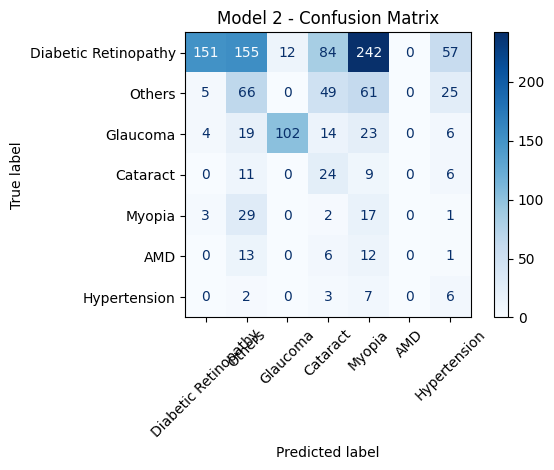

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_model2 = confusion_matrix(
    y_true_model2,
    y_pred_model2,
    labels=np.arange(7)
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_model2,
    display_labels=abnormal_classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Model 2 - Confusion Matrix")
plt.tight_layout()
plt.show()

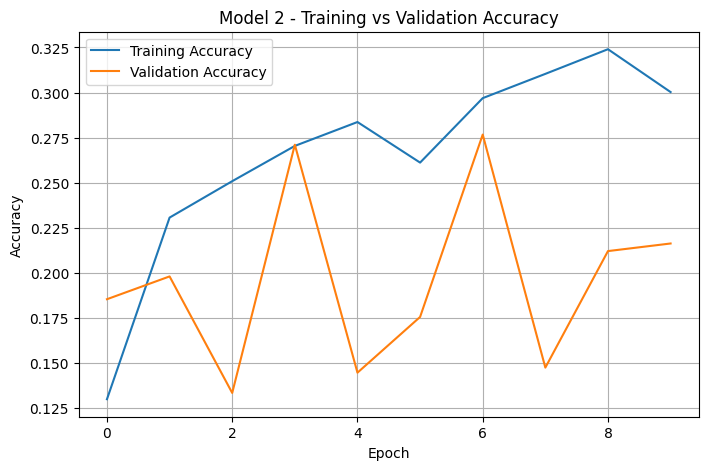

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_model2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_model2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

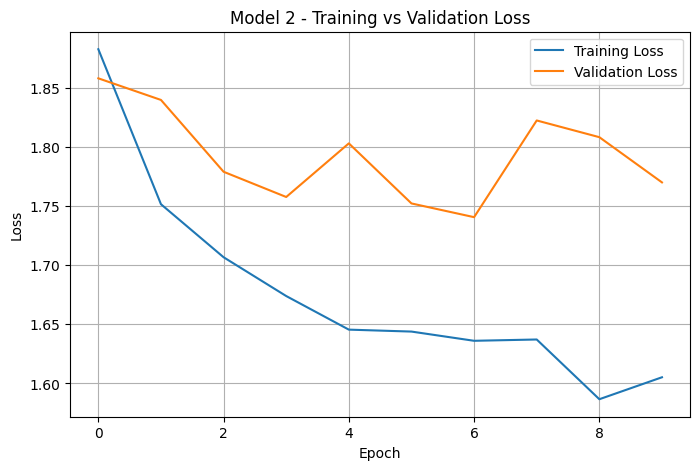

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_model2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_model2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("images_dir:", "images_dir" in globals())
print("train_model2_dataset:", "train_model2_dataset" in globals())
print("val_model2_dataset:", "val_model2_dataset" in globals())
print("test_model2_dataset:", "test_model2_dataset" in globals())
print("model2_cnn:", "model2_cnn" in globals())
print("history_model2:", "history_model2" in globals())

images_dir: False
train_model2_dataset: False
val_model2_dataset: False
test_model2_dataset: False
model2_cnn: False
history_model2: False


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/EyeDiseaseDataset.zip'

print("ZIP exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("ZIP size (GB):", round(os.path.getsize(zip_path) / (1024**3), 2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP exists: True
ZIP size (GB): 3.8


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/EyeDiseaseDataset.zip"
extract_dir = "/content/eye_dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    image_files = [
        name for name in zip_ref.namelist()
        if name.startswith("images/")
    ]

    zip_ref.extractall(
        extract_dir,
        members=image_files
    )

print("Images extracted successfully!")

images_dir = "/content/eye_dataset/images"

image_count = len([
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Images found:", image_count)
print("Images directory:", images_dir)

Images extracted successfully!
Images found: 11839
Images directory: /content/eye_dataset/images


In [ ]:
import pandas as pd
import os

metadata_path = "/content/eye_dataset/metadata.csv"
val_path = "/content/eye_dataset/splits/val.csv"

metadata = pd.read_csv(metadata_path)
val_df = pd.read_csv(val_path)

print("Metadata shape:", metadata.shape)
print("Validation shape:", val_df.shape)

print("\nMetadata columns:")
print(metadata.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/eye_dataset/metadata.csv'

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/EyeDiseaseDataset.zip"
extract_dir = "/content/eye_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files_to_extract = [
        "metadata.csv",
        "splits/val.csv"
    ]

    zip_ref.extractall(
        extract_dir,
        members=files_to_extract
    )

print("Metadata files extracted successfully!")

print("metadata.csv exists:",
      os.path.exists("/content/eye_dataset/metadata.csv"))

print("val.csv exists:",
      os.path.exists("/content/eye_dataset/splits/val.csv"))

Metadata files extracted successfully!
metadata.csv exists: True
val.csv exists: True


In [ ]:
import pandas as pd
import numpy as np

metadata = pd.read_csv("/content/eye_dataset/metadata.csv")
val_df = pd.read_csv("/content/eye_dataset/splits/val.csv")

print("Metadata shape:", metadata.shape)
print("Validation shape:", val_df.shape)

print("\nValidation images:", len(val_df))
print("Validation unique images:", val_df["filename"].nunique())

Metadata shape: (11839, 4)
Validation shape: (1197, 4)

Validation images: 1197
Validation unique images: 1197


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Files that belong to the official validation set
val_filenames = set(val_df["filename"])

# Remaining data after removing validation images
remaining_df = metadata[
    ~metadata["filename"].isin(val_filenames)
].copy()

print("Remaining images:", len(remaining_df))

Remaining images: 10642


In [ ]:
import re

def get_group_id(filename):
    """
    Create a group ID for ODIR images.
    Example:
    ODIR_4677_left.jpg  -> ODIR_4677
    ODIR_4677_right.jpg -> ODIR_4677

    For other datasets, each image is treated as its own group.
    """

    if filename.startswith("ODIR_"):
        match = re.match(r"(ODIR_\d+)_", filename)

        if match:
            return match.group(1)

    return filename


# Create group IDs
remaining_df["group_id"] = remaining_df["filename"].apply(get_group_id)

val_df["group_id"] = val_df["filename"].apply(get_group_id)

print("Remaining images:", len(remaining_df))
print("Remaining groups:", remaining_df["group_id"].nunique())
print("Validation groups:", val_df["group_id"].nunique())

Remaining images: 10642
Remaining groups: 7811
Validation groups: 1157


In [ ]:
validation_groups = set(val_df["group_id"])

train_test_pool = remaining_df[
    ~remaining_df["group_id"].isin(validation_groups)
].copy()

print("Images available for Train/Test:", len(train_test_pool))
print("Groups available for Train/Test:", train_test_pool["group_id"].nunique())
print(
    "Images excluded because their group appears in Validation:",
    len(remaining_df) - len(train_test_pool)
)

Images available for Train/Test: 10013
Groups available for Train/Test: 7182
Images excluded because their group appears in Validation: 629


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = train_test_pool["filename"]
y = train_test_pool["unified_label"]
groups = train_test_pool["group_id"]

train_indices, test_indices = next(
    sgkf.split(X, y, groups)
)

train_df = train_test_pool.iloc[train_indices].copy()
test_df = train_test_pool.iloc[test_indices].copy()

print("Train images:", len(train_df))
print("Test images:", len(test_df))
print("Validation images:", len(val_df))

print("\nTotal:", len(train_df) + len(test_df) + len(val_df))

Train images: 8013
Test images: 2000
Validation images: 1197

Total: 11210


In [ ]:
images_dir = "/content/eye_dataset/images"

class_names = [
    "Normal",
    "Diabetic Retinopathy",
    "Others",
    "Glaucoma",
    "Cataract",
    "Myopia",
    "AMD",
    "Hypertension"
]

class_to_index = {
    "Normal": 0,
    "Diabetic Retinopathy": 1,
    "Others": 2,
    "Glaucoma": 3,
    "Cataract": 4,
    "Myopia": 5,
    "AMD": 6,
    "Hypertension": 7
}

abnormal_classes = [
    "Diabetic Retinopathy",
    "Others",
    "Glaucoma",
    "Cataract",
    "Myopia",
    "AMD",
    "Hypertension"
]

model2_class_to_index = {
    "Diabetic Retinopathy": 0,
    "Others": 1,
    "Glaucoma": 2,
    "Cataract": 3,
    "Myopia": 4,
    "AMD": 5,
    "Hypertension": 6
}

model2_index_to_class = {
    v: k for k, v in model2_class_to_index.items()
}

print("Variables restored successfully!")
print("Images directory:", images_dir)
print("Model 2 classes:", abnormal_classes)

Variables restored successfully!
Images directory: /content/eye_dataset/images
Model 2 classes: ['Diabetic Retinopathy', 'Others', 'Glaucoma', 'Cataract', 'Myopia', 'AMD', 'Hypertension']


In [ ]:
# Create Model 2 dataframes again

train_model2_df = train_df[
    train_df["unified_label"].isin(abnormal_classes)
].copy()

val_model2_df = val_df[
    val_df["unified_label"].isin(abnormal_classes)
].copy()

test_model2_df = test_df[
    test_df["unified_label"].isin(abnormal_classes)
].copy()

# Create numerical labels
train_model2_labels = (
    train_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)

val_model2_labels = (
    val_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)

test_model2_labels = (
    test_model2_df["unified_label"]
    .map(model2_class_to_index)
    .values
)

print("Model 2 DataFrames restored!")

print("\nTrain:", len(train_model2_df))
print("Validation:", len(val_model2_df))
print("Test:", len(test_model2_df))

print("\nTrain labels:", np.bincount(train_model2_labels))
print("Validation labels:", np.bincount(val_model2_labels))
print("Test labels:", np.bincount(test_model2_labels))

Model 2 DataFrames restored!

Train: 4756
Validation: 712
Test: 1227

Train labels: [2775  694  629  228  188  190   52]
Validation labels: [408 110  93  34  30  28   9]
Test labels: [701 206 168  50  52  32  18]


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)
print("ResNet50 imported successfully!")

TensorFlow version: 2.20.0
ResNet50 imported successfully!


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def load_image_resnet(filename, label):
    image_path = tf.strings.join([images_dir, "/", filename])

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)

    # ResNet50 preprocessing
    image = preprocess_input(image)

    return image, label

print("ResNet50 image loader created successfully!")

ResNet50 image loader created successfully!


In [ ]:
# Test ResNet50 preprocessing on one image

sample_filename = train_model2_df.iloc[0]["filename"]
sample_label = train_model2_labels[0]

sample_image, sample_label = load_image_resnet(
    tf.constant(sample_filename),
    tf.constant(sample_label)
)

print("Filename:", sample_filename)
print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Pixel min:", tf.reduce_min(sample_image).numpy())
print("Pixel max:", tf.reduce_max(sample_image).numpy())
print("Label:", sample_label.numpy())

Filename: ACRIMA_Im310_g_ACRIMA.jpg
Image shape: (224, 224, 3)
Image dtype: <dtype: 'float32'>
Pixel min: -85.290375
Pixel max: 127.32
Label: 2


In [ ]:
def create_resnet_dataset(df, labels, shuffle=False):
    filenames = df["filename"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filenames, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.map(
        load_image_resnet,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_resnet_dataset = create_resnet_dataset(
    train_model2_df,
    train_model2_labels,
    shuffle=True
)

val_resnet_dataset = create_resnet_dataset(
    val_model2_df,
    val_model2_labels,
    shuffle=False
)

test_resnet_dataset = create_resnet_dataset(
    test_model2_df,
    test_model2_labels,
    shuffle=False
)

print("ResNet50 Model 2 datasets created successfully!")

ResNet50 Model 2 datasets created successfully!


In [ ]:
# Verify one ResNet50 batch

images_batch, labels_batch = next(iter(train_resnet_dataset))

print("Images shape:", images_batch.shape)
print("Images dtype:", images_batch.dtype)
print("Labels shape:", labels_batch.shape)
print("Labels dtype:", labels_batch.dtype)
print("Pixel min:", tf.reduce_min(images_batch).numpy())
print("Pixel max:", tf.reduce_max(images_batch).numpy())

Images shape: (32, 224, 224, 3)
Images dtype: <dtype: 'float32'>
Labels shape: (32,)
Labels dtype: <dtype: 'int64'>
Pixel min: -123.68
Pixel max: 151.061


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# Load ResNet50 with ImageNet pretrained weights
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Build Model 2
resnet_model2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(7, activation="softmax")
])

print("ResNet50 Model 2 created successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 Model 2 created successfully!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

resnet_model2_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_model2_labels),
    y=train_model2_labels
)

resnet_model2_class_weights = {
    i: weight
    for i, weight in enumerate(resnet_model2_class_weights_array)
}

print("ResNet50 Model 2 class weights:")
for i, weight in resnet_model2_class_weights.items():
    print(f"{i} - {model2_index_to_class[i]}: {weight:.3f}")

ResNet50 Model 2 class weights:
0 - Diabetic Retinopathy: 0.245
1 - Others: 0.979
2 - Glaucoma: 1.080
3 - Cataract: 2.980
4 - Myopia: 3.614
5 - AMD: 3.576
6 - Hypertension: 13.066


In [ ]:
resnet_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("ResNet50 Model 2 compiled successfully!")

ResNet50 Model 2 compiled successfully!


In [ ]:
early_stopping_resnet2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_resnet_model2 = resnet_model2.fit(
    train_resnet_dataset,
    validation_data=val_resnet_dataset,
    epochs=10,
    class_weight=resnet_model2_class_weights,
    callbacks=[early_stopping_resnet2]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 124s 685ms/step - accuracy: 0.4725 - loss: 1.4592 - val_accuracy: 0.4817 - val_loss: 1.1716
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 565ms/step - accuracy: 0.4966 - loss: 1.1850 - val_accuracy: 0.4579 - val_loss: 1.3146
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 558ms/step - accuracy: 0.4878 - loss: 1.1868 - val_accuracy: 0.4677 - val_loss: 1.2222
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 93s 627ms/step - accuracy: 0.5114 - loss: 1.0759 - val_accuracy: 0.4466 - val_loss: 1.3066


In [ ]:
test_loss_resnet2, test_accuracy_resnet2 = resnet_model2.evaluate(
    test_resnet_dataset
)

print(f"ResNet50 Model 2 Test Loss: {test_loss_resnet2:.4f}")
print(f"ResNet50 Model 2 Test Accuracy: {test_accuracy_resnet2:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 767ms/step - accuracy: 0.5249 - loss: 1.1087
ResNet50 Model 2 Test Loss: 1.1087
ResNet50 Model 2 Test Accuracy: 0.5249


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_true_resnet2 = []
y_pred_resnet2 = []

for images, labels in test_resnet_dataset:
    predictions = resnet_model2.predict(images, verbose=0)

    y_true_resnet2.extend(labels.numpy())
    y_pred_resnet2.extend(np.argmax(predictions, axis=1))

y_true_resnet2 = np.array(y_true_resnet2)
y_pred_resnet2 = np.array(y_pred_resnet2)

# Classification report
print("ResNet50 Model 2 Classification Report:\n")

print(
    classification_report(
        y_true_resnet2,
        y_pred_resnet2,
        target_names=abnormal_classes,
        zero_division=0
    )
)

ResNet50 Model 2 Classification Report:

                      precision    recall  f1-score   support

Diabetic Retinopathy       0.88      0.54      0.67       701
              Others       0.29      0.32      0.30       206
            Glaucoma       0.99      0.62      0.77       168
            Cataract       0.64      0.74      0.69        50
              Myopia       0.38      0.94      0.54        52
                 AMD       0.09      0.16      0.11        32
        Hypertension       0.02      0.28      0.04        18

            accuracy                           0.52      1227
           macro avg       0.47      0.51      0.45      1227
        weighted avg       0.73      0.52      0.59      1227



<Figure size 900x800 with 0 Axes>

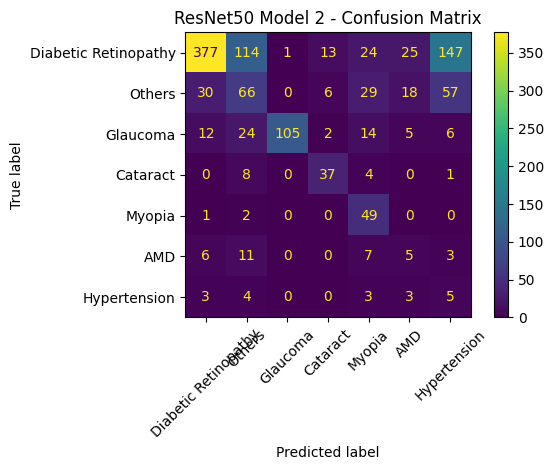

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_resnet2 = confusion_matrix(
    y_true_resnet2,
    y_pred_resnet2
)

plt.figure(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet2,
    display_labels=abnormal_classes
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("ResNet50 Model 2 - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Prepare ResNet50 for fine-tuning

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
for layer in base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a much smaller learning rate
resnet_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Fine-tuning setup completed!")
print("Trainable ResNet50 layers:", trainable_layers)

Fine-tuning setup completed!
Trainable ResNet50 layers: 21


In [ ]:
early_stopping_resnet2_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_resnet_model2_ft = resnet_model2.fit(
    train_resnet_dataset,
    validation_data=val_resnet_dataset,
    epochs=7,
    class_weight=resnet_model2_class_weights,
    callbacks=[early_stopping_resnet2_ft]
)

Epoch 1/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 121s 651ms/step - accuracy: 0.5235 - loss: 1.1524 - val_accuracy: 0.4775 - val_loss: 1.1999
Epoch 2/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 559ms/step - accuracy: 0.5311 - loss: 1.0272 - val_accuracy: 0.4916 - val_loss: 1.1764
Epoch 3/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 153s 631ms/step - accuracy: 0.5406 - loss: 0.9924 - val_accuracy: 0.4789 - val_loss: 1.1746
Epoch 4/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 142s 629ms/step - accuracy: 0.5620 - loss: 0.9178 - val_accuracy: 0.4930 - val_loss: 1.1385
Epoch 5/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 560ms/step - accuracy: 0.5643 - loss: 0.8406 - val_accuracy: 0.5337 - val_loss: 1.1089
Epoch 6/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 553ms/step - accuracy: 0.5923 - loss: 0.7646 - val_accuracy: 0.5056 - val_loss: 1.1323
Epoch 7/7
149/149 ━━━━━━━━━━━━━━━━━━━━ 85s 569ms/step - accuracy: 0.6053 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 1.1906


In [ ]:
test_loss_resnet2_ft, test_accuracy_resnet2_ft = resnet_model2.evaluate(
    test_resnet_dataset
)

print(f"ResNet50 Model 2 Fine-Tuned Test Loss: {test_loss_resnet2_ft:.4f}")
print(f"ResNet50 Model 2 Fine-Tuned Test Accuracy: {test_accuracy_resnet2_ft:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 738ms/step - accuracy: 0.5681 - loss: 1.0550
ResNet50 Model 2 Fine-Tuned Test Loss: 1.0550
ResNet50 Model 2 Fine-Tuned Test Accuracy: 0.5681


In [ ]:
from sklearn.metrics import classification_report

y_true_resnet2_ft = []
y_pred_resnet2_ft = []

for images, labels in test_resnet_dataset:
    predictions = resnet_model2.predict(images, verbose=0)

    y_true_resnet2_ft.extend(labels.numpy())
    y_pred_resnet2_ft.extend(np.argmax(predictions, axis=1))

y_true_resnet2_ft = np.array(y_true_resnet2_ft)
y_pred_resnet2_ft = np.array(y_pred_resnet2_ft)

print("ResNet50 Model 2 Fine-Tuned Classification Report:\n")

print(
    classification_report(
        y_true_resnet2_ft,
        y_pred_resnet2_ft,
        target_names=abnormal_classes,
        zero_division=0
    )
)

ResNet50 Model 2 Fine-Tuned Classification Report:

                      precision    recall  f1-score   support

Diabetic Retinopathy       0.96      0.50      0.65       701
              Others       0.32      0.55      0.40       206
            Glaucoma       0.84      0.77      0.80       168
            Cataract       0.47      0.82      0.60        50
              Myopia       0.73      0.85      0.79        52
                 AMD       0.11      0.47      0.18        32
        Hypertension       0.07      0.28      0.11        18

            accuracy                           0.57      1227
           macro avg       0.50      0.60      0.51      1227
        weighted avg       0.77      0.57      0.62      1227



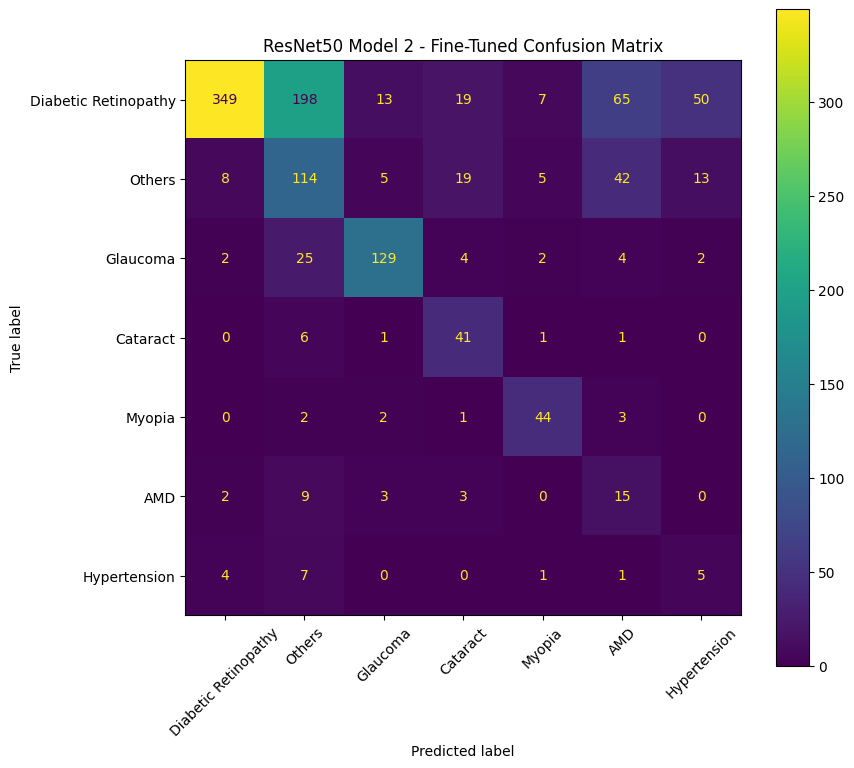

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_resnet2_ft = confusion_matrix(
    y_true_resnet2_ft,
    y_pred_resnet2_ft
)

fig, ax = plt.subplots(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet2_ft,
    display_labels=abnormal_classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("ResNet50 Model 2 - Fine-Tuned Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Create binary labels for ResNet50 Model 1
# 0 = Normal
# 1 = Abnormal

train_model1_labels = (
    train_df["unified_label"] != "Normal"
).astype(np.int32).values

val_model1_labels = (
    val_df["unified_label"] != "Normal"
).astype(np.int32).values

test_model1_labels = (
    test_df["unified_label"] != "Normal"
).astype(np.int32).values

print("Model 1 labels created successfully!")

print("\nTrain:")
print("Normal:", np.sum(train_model1_labels == 0))
print("Abnormal:", np.sum(train_model1_labels == 1))

print("\nValidation:")
print("Normal:", np.sum(val_model1_labels == 0))
print("Abnormal:", np.sum(val_model1_labels == 1))

print("\nTest:")
print("Normal:", np.sum(test_model1_labels == 0))
print("Abnormal:", np.sum(test_model1_labels == 1))

Model 1 labels created successfully!

Train:
Normal: 3257
Abnormal: 4756

Validation:
Normal: 485
Abnormal: 712

Test:
Normal: 773
Abnormal: 1227


In [ ]:
train_resnet_model1_dataset = create_resnet_dataset(
    train_df,
    train_model1_labels,
    shuffle=True
)

val_resnet_model1_dataset = create_resnet_dataset(
    val_df,
    val_model1_labels,
    shuffle=False
)

test_resnet_model1_dataset = create_resnet_dataset(
    test_df,
    test_model1_labels,
    shuffle=False
)

print("ResNet50 Model 1 datasets created successfully!")

ResNet50 Model 1 datasets created successfully!


In [ ]:
images_batch_m1, labels_batch_m1 = next(
    iter(train_resnet_model1_dataset)
)

print("Images shape:", images_batch_m1.shape)
print("Images dtype:", images_batch_m1.dtype)
print("Labels shape:", labels_batch_m1.shape)
print("Labels dtype:", labels_batch_m1.dtype)
print("Pixel min:", tf.reduce_min(images_batch_m1).numpy())
print("Pixel max:", tf.reduce_max(images_batch_m1).numpy())
print("Unique labels:", np.unique(labels_batch_m1.numpy()))

Images shape: (32, 224, 224, 3)
Images dtype: <dtype: 'float32'>
Labels shape: (32,)
Labels dtype: <dtype: 'int32'>
Pixel min: -123.68
Pixel max: 147.061
Unique labels: [0 1]


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50
base_model_m1 = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model_m1.trainable = False

# Build Model 1: Normal vs Abnormal
resnet_model1 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model_m1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

print("ResNet50 Model 1 created successfully!")

ResNet50 Model 1 created successfully!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

resnet_model1_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_model1_labels),
    y=train_model1_labels
)

resnet_model1_class_weights = {
    i: weight
    for i, weight in enumerate(resnet_model1_class_weights_array)
}

print("ResNet50 Model 1 class weights:")

print(
    f"0 - Normal: "
    f"{resnet_model1_class_weights[0]:.3f}"
)

print(
    f"1 - Abnormal: "
    f"{resnet_model1_class_weights[1]:.3f}"
)

ResNet50 Model 1 class weights:
0 - Normal: 1.230
1 - Abnormal: 0.842


In [ ]:
resnet_model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

print("ResNet50 Model 1 compiled successfully!")

ResNet50 Model 1 compiled successfully!


In [ ]:
early_stopping_resnet1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_resnet_model1 = resnet_model1.fit(
    train_resnet_model1_dataset,
    validation_data=val_resnet_model1_dataset,
    epochs=10,
    class_weight=resnet_model1_class_weights,
    callbacks=[early_stopping_resnet1]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 170s 605ms/step - accuracy: 0.7000 - loss: 0.5584 - val_accuracy: 0.7402 - val_loss: 0.5327
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 138s 551ms/step - accuracy: 0.7433 - loss: 0.4844 - val_accuracy: 0.7327 - val_loss: 0.5280
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 168s 669ms/step - accuracy: 0.7493 - loss: 0.4635 - val_accuracy: 0.7251 - val_loss: 0.5166
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 561ms/step - accuracy: 0.7671 - loss: 0.4471 - val_accuracy: 0.7510 - val_loss: 0.5234
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 141s 557ms/step - accuracy: 0.7765 - loss: 0.4291 - val_accuracy: 0.7569 - val_loss: 0.5082
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 140s 559ms/step - accuracy: 0.7834 - loss: 0.4215 - val_accuracy: 0.7544 - val_loss: 0.5211
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 142s 559ms/step - accuracy: 0.7861 - loss: 0.4143 - val_accuracy: 0.7485 - val_loss: 0.5211
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 136s 543ms/step - accuracy: 0.7819 -

In [ ]:
test_loss_resnet1, test_accuracy_resnet1 = resnet_model1.evaluate(
    test_resnet_model1_dataset
)

print(f"ResNet50 Model 1 Test Loss: {test_loss_resnet1:.4f}")
print(f"ResNet50 Model 1 Test Accuracy: {test_accuracy_resnet1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 674ms/step - accuracy: 0.8035 - loss: 0.4148
ResNet50 Model 1 Test Loss: 0.4148
ResNet50 Model 1 Test Accuracy: 0.8035


In [ ]:
from sklearn.metrics import classification_report

y_true_resnet1 = []
y_pred_resnet1 = []

for images, labels in test_resnet_model1_dataset:
    predictions = resnet_model1.predict(images, verbose=0)

    y_true_resnet1.extend(labels.numpy())
    y_pred_resnet1.extend(
        (predictions.ravel() >= 0.5).astype(int)
    )

y_true_resnet1 = np.array(y_true_resnet1)
y_pred_resnet1 = np.array(y_pred_resnet1)

print("ResNet50 Model 1 Classification Report:\n")

print(
    classification_report(
        y_true_resnet1,
        y_pred_resnet1,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

ResNet50 Model 1 Classification Report:

              precision    recall  f1-score   support

      Normal       0.77      0.71      0.74       773
    Abnormal       0.82      0.86      0.84      1227

    accuracy                           0.80      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



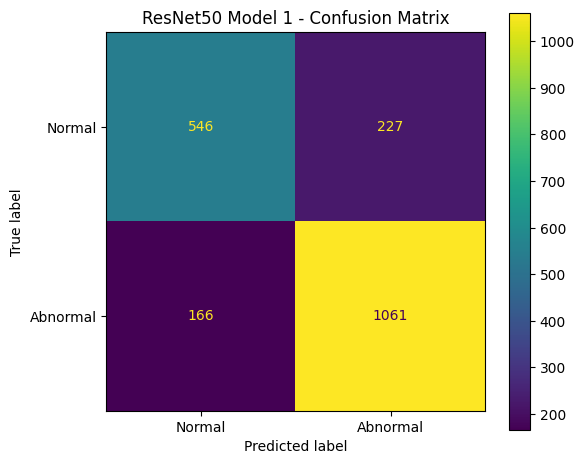

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_resnet1 = confusion_matrix(
    y_true_resnet1,
    y_pred_resnet1
)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet1,
    display_labels=["Normal", "Abnormal"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("ResNet50 Model 1 - Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50",
        "ResNet50",
        "ResNet50 Fine-Tuned"
    ],
    "Task": [
        "Model 1 - Normal vs Abnormal",
        "Model 1 - Normal vs Abnormal",
        "Model 2 - 7 Disease Classes",
        "Model 2 - 7 Disease Classes"
    ],
    "Test Accuracy": [
        0.6800,
        test_accuracy_resnet1,
        0.5249,
        test_accuracy_resnet2_ft
    ],
    "Macro F1": [
        0.65,
        0.79,
        0.45,
        0.51
    ]
})

final_results["Test Accuracy"] = (
    final_results["Test Accuracy"] * 100
).round(2)

final_results["Macro F1"] = (
    final_results["Macro F1"] * 100
).round(2)

display(final_results)

,Model,Task,Test Accuracy,Macro F1
0,Custom CNN,Model 1 - Normal vs Abnormal,68.00,65.0
1,ResNet50,Model 1 - Normal vs Abnormal,80.35,79.0
2,ResNet50,Model 2 - 7 Disease Classes,52.49,45.0
3,ResNet50 Fine-Tuned,Model 2 - 7 Disease Classes,56.81,51.0


In [ ]:
# End-to-End Evaluation
# Step 1: Define the class mappings

class_names = [
    "Normal",
    "Diabetic Retinopathy",
    "Others",
    "Glaucoma",
    "Cataract",
    "Myopia",
    "AMD",
    "Hypertension"
]

class_to_index = {
    "Normal": 0,
    "Diabetic Retinopathy": 1,
    "Others": 2,
    "Glaucoma": 3,
    "Cataract": 4,
    "Myopia": 5,
    "AMD": 6,
    "Hypertension": 7
}

index_to_class = {
    v: k for k, v in class_to_index.items()
}

print("Classes:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

print("\nTest set size:", len(test_df))

Classes:
0: Normal
1: Diabetic Retinopathy
2: Others
3: Glaucoma
4: Cataract
5: Myopia
6: AMD
7: Hypertension

Test set size: 2000


In [ ]:
# Step 2: Get Model 1 predictions on the test set

model1_probs = resnet_model1.predict(
    test_resnet_model1_dataset,
    verbose=1
)

# Convert probabilities to binary predictions
y_pred_model1 = (model1_probs.ravel() >= 0.5).astype(int)

print("Number of predictions:", len(y_pred_model1))
print("Unique predictions:", np.unique(y_pred_model1))

print("\nNormal predictions:", np.sum(y_pred_model1 == 0))
print("Abnormal predictions:", np.sum(y_pred_model1 == 1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 570ms/step
Number of predictions: 2000
Unique predictions: [0 1]

Normal predictions: 712
Abnormal predictions: 1288


In [ ]:
# Step 3: Send Model 1's predicted-abnormal images to Model 2

# Get the test filenames in the same order as the predictions
test_filenames = test_df["filename"].values

# Find images predicted as Abnormal by Model 1
abnormal_mask = y_pred_model1 == 1

abnormal_filenames = test_filenames[abnormal_mask]

print("Number of images sent to Model 2:", len(abnormal_filenames))
print("First 5 filenames:")
print(abnormal_filenames[:5])

Number of images sent to Model 2: 1288
First 5 filenames:
['ACRIMA_Im004_ACRIMA.jpg' 'ACRIMA_Im031_ACRIMA.jpg'
 'ACRIMA_Im043_ACRIMA.jpg' 'ACRIMA_Im072_ACRIMA.jpg'
 'ACRIMA_Im080_ACRIMA.jpg']


In [ ]:
# Step 4: Create a dataset for the images predicted as Abnormal

def load_image_resnet_e2e(filename):
    image_path = tf.strings.join([images_dir, "/", filename])

    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # ResNet50 ImageNet preprocessing
    image = preprocess_input(image)

    return image


e2e_model2_dataset = tf.data.Dataset.from_tensor_slices(
    abnormal_filenames
)

e2e_model2_dataset = (
    e2e_model2_dataset
    .map(load_image_resnet_e2e, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Model 2 dataset is ready.")
print("Number of images:", len(abnormal_filenames))

Model 2 dataset is ready.
Number of images: 1288


In [ ]:
# Step 5: Predict the disease class for the images sent to Model 2

model2_probs_e2e = resnet_model2.predict(
    e2e_model2_dataset,
    verbose=1
)

# Get the predicted class index
y_pred_model2_e2e = np.argmax(
    model2_probs_e2e,
    axis=1
)

print("Number of Model 2 predictions:", len(y_pred_model2_e2e))
print("Unique predicted classes:", np.unique(y_pred_model2_e2e))

print("\nPredicted class counts:")

for class_index in range(7):
    count = np.sum(y_pred_model2_e2e == class_index)
    print(
        f"{model2_index_to_class[class_index]}: {count}"
    )

41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 690ms/step
Number of Model 2 predictions: 1288
Unique predicted classes: [0 1 2 3 4 5 6]

Predicted class counts:
Diabetic Retinopathy: 363
Others: 374
Glaucoma: 145
Cataract: 103
Myopia: 62
AMD: 155
Hypertension: 86


In [ ]:
# Step 6: Prepare the true labels for the End-to-End evaluation

# True 8-class labels for the complete test set
y_true_e2e = test_df["unified_label"].map(class_to_index).values

# Create final predictions for the complete test set
# Start by assuming everything is Normal
y_pred_e2e = np.zeros(len(test_df), dtype=int)

# Model 1 predicted Abnormal -> use Model 2 prediction
abnormal_indices = np.where(abnormal_mask)[0]

# Convert Model 2's 0-6 class indices to the original 8-class indices
# Model 2 does not have a Normal class
for test_index, model2_prediction in zip(
    abnormal_indices,
    y_pred_model2_e2e
):
    disease_name = model2_index_to_class[model2_prediction]
    y_pred_e2e[test_index] = class_to_index[disease_name]

print("True labels:", len(y_true_e2e))
print("Final predictions:", len(y_pred_e2e))

print("\nUnique true classes:", np.unique(y_true_e2e))
print("Unique predicted classes:", np.unique(y_pred_e2e))

True labels: 2000
Final predictions: 2000

Unique true classes: [0 1 2 3 4 5 6 7]
Unique predicted classes: [0 1 2 3 4 5 6 7]


End-to-End Accuracy: 0.5800
End-to-End Accuracy: 58.00%

Classification Report:

                      precision    recall  f1-score   support

              Normal       0.77      0.71      0.74       773
Diabetic Retinopathy       0.91      0.47      0.62       701
              Others       0.22      0.39      0.28       206
            Glaucoma       0.69      0.60      0.64       168
            Cataract       0.38      0.78      0.51        50
              Myopia       0.71      0.85      0.77        52
                 AMD       0.09      0.44      0.15        32
        Hypertension       0.06      0.28      0.10        18

            accuracy                           0.58      2000
           macro avg       0.48      0.56      0.48      2000
        weighted avg       0.73      0.58      0.62      2000



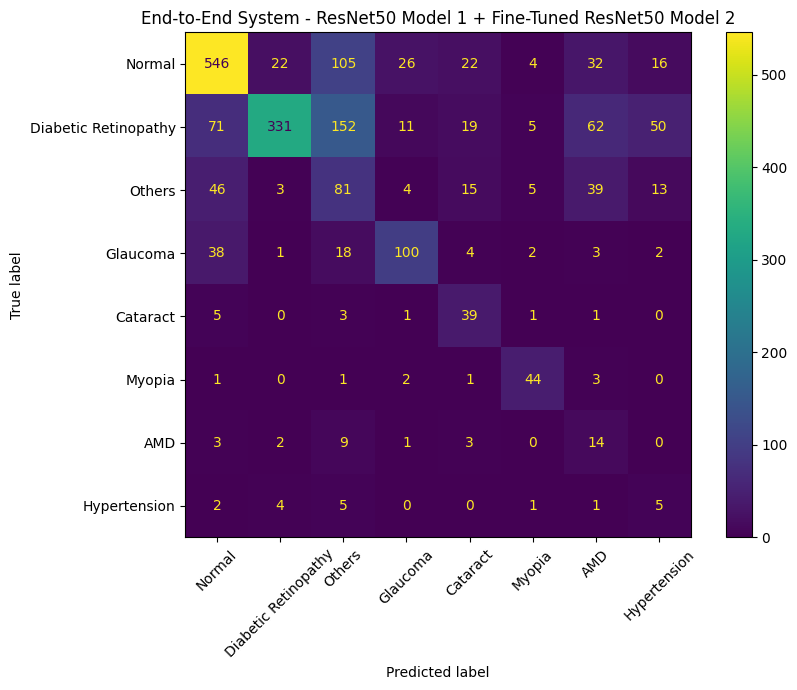

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Overall accuracy
e2e_accuracy = accuracy_score(
    y_true_e2e,
    y_pred_e2e
)

print(f"End-to-End Accuracy: {e2e_accuracy:.4f}")
print(f"End-to-End Accuracy: {e2e_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_true_e2e,
        y_pred_e2e,
        labels=list(range(8)),
        target_names=class_names,
        zero_division=0
    )
)

# Confusion Matrix
cm_e2e = confusion_matrix(
    y_true_e2e,
    y_pred_e2e,
    labels=list(range(8))
)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_e2e,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

ax.set_title(
    "End-to-End System - ResNet50 Model 1 + Fine-Tuned ResNet50 Model 2"
)

plt.tight_layout()
plt.show()

# Results and Model Comparison

This section summarizes the performance of the trained models on the test set.

The project uses a two-stage classification architecture:

1. **Model 1:** Normal vs Abnormal
2. **Model 2:** Classification of the 7 abnormal disease classes

The pretrained ResNet50 model was evaluated both with frozen pretrained features and after fine-tuning.

In [ ]:
# Final Model Comparison

results_comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50 (Frozen)",
        "Custom CNN",
        "ResNet50 (Frozen)",
        "ResNet50 (Fine-Tuned)",
        "End-to-End System"
    ],
    "Task": [
        "Model 1 - Normal vs Abnormal",
        "Model 1 - Normal vs Abnormal",
        "Model 2 - 7 Disease Classes",
        "Model 2 - 7 Disease Classes",
        "Model 2 - 7 Disease Classes",
        "Model 1 → Model 2"
    ],
    "Test Accuracy (%)": [
        68.00,
        80.35,
        29.83,
        52.49,
        56.81,
        58.00
    ],
    "Macro F1 (%)": [
        65.00,
        79.00,
        24.62,
        45.00,
        51.00,
        48.00
    ]
})

display(results_comparison)

,Model,Task,Test Accuracy (%),Macro F1 (%)
0,Custom CNN,Model 1 - Normal vs Abnormal,68.00,65.00
1,ResNet50 (Frozen),Model 1 - Normal vs Abnormal,80.35,79.00
2,Custom CNN,Model 2 - 7 Disease Classes,29.83,24.62
3,ResNet50 (Frozen),Model 2 - 7 Disease Classes,52.49,45.00
4,ResNet50 (Fine-Tuned),Model 2 - 7 Disease Classes,56.81,51.00
5,End-to-End System,Model 1 → Model 2,58.00,48.00


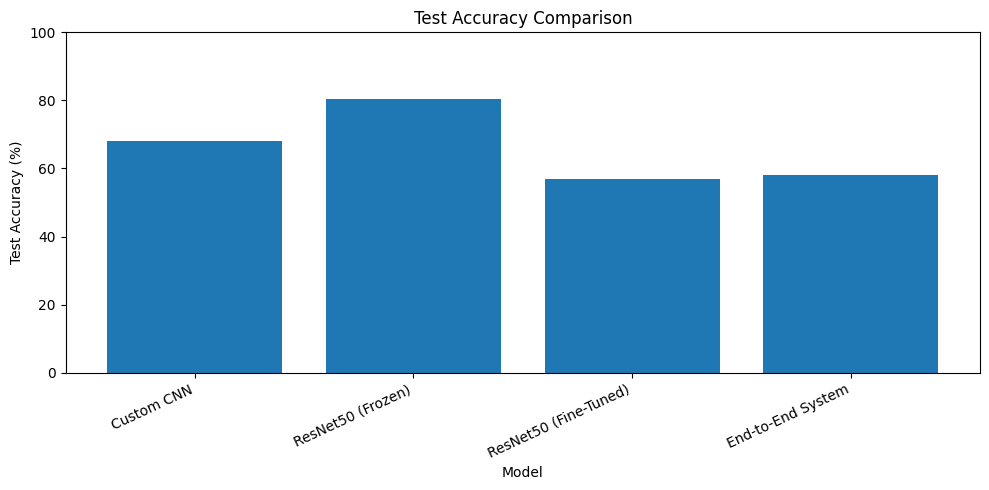

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_comparison["Model"],
    results_comparison["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison")

plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

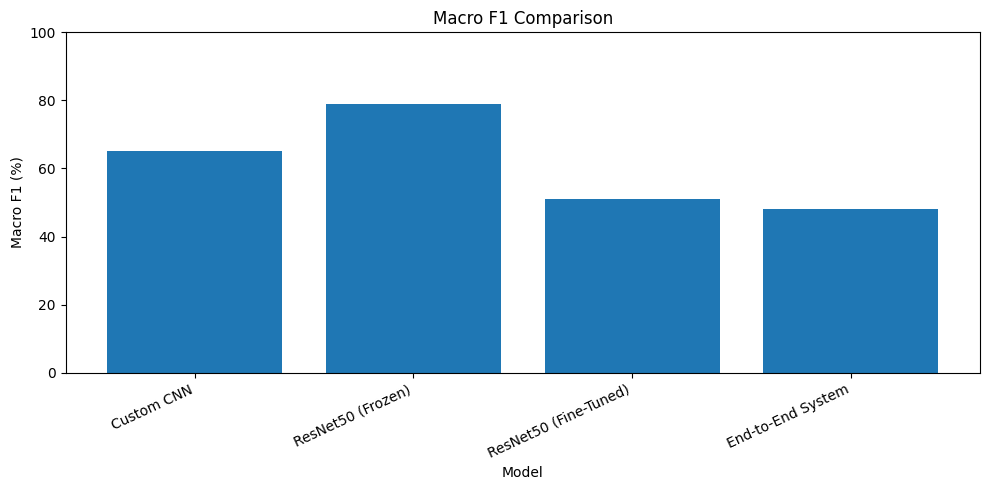

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_comparison["Model"],
    results_comparison["Macro F1 (%)"]
)

plt.ylabel("Macro F1 (%)")
plt.xlabel("Model")
plt.title("Macro F1 Comparison")

plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Results Analysis

The results show that the pretrained ResNet50 architecture performed better than the custom CNN, particularly for the binary classification task.

For Model 1 (Normal vs Abnormal), the ResNet50 model achieved a test accuracy of 80.35% and a macro F1-score of 79.00%, compared with 68.00% accuracy and 65.00% macro F1-score for the custom CNN.

For Model 2, which classifies the seven abnormal disease categories, the custom CNN achieved 29.83% accuracy and 24.62% macro F1-score. The frozen ResNet50 improved these results to 52.49% accuracy and 45.00% macro F1-score. After fine-tuning the ResNet50, performance increased further to 56.81% accuracy and 51.00% macro F1-score.

The End-to-End system, which combines Model 1 and the fine-tuned Model 2, achieved 58.00% accuracy and 48.00% macro F1-score on the test set.

The lower performance on the seven-class classification task is related to the strong class imbalance in the dataset. Some classes, such as Hypertension and AMD, contain substantially fewer training examples than Diabetic Retinopathy and Normal images. The classification reports and confusion matrices also show that the smaller classes are generally more difficult to classify consistently.

Overall, the results demonstrate the benefit of transfer learning and fine-tuning for this medical image classification task. However, the performance of the seven-class classifier indicates that additional data, improved class-balancing strategies, and further model optimization could be explored in future work.

# Conclusion

This project developed a two-stage deep learning system for eye disease classification using fundus images.

The first model performs binary classification to distinguish between Normal and Abnormal images. The second model classifies abnormal images into seven disease categories: Diabetic Retinopathy, Others, Glaucoma, Cataract, Myopia, AMD, and Hypertension.

A custom CNN was implemented from scratch and compared with a pretrained ResNet50 model. The results showed that ResNet50 provided substantially better performance than the custom CNN. Fine-tuning the pretrained ResNet50 further improved the seven-class classification performance.

The final End-to-End system achieved 58.00% test accuracy and a 48.00% macro F1-score. The results also highlighted the effect of class imbalance, particularly for the minority classes such as Hypertension and AMD.

## Limitations

- The dataset is strongly imbalanced across the eight classes.
- Some disease classes contain relatively few training examples.
- The seven-class classification task remains challenging, especially for minority classes.
- The official dataset provides a validation split, while the train/test split had to be reconstructed while avoiding overlap with validation groups.
- The End-to-End performance is affected by errors made by both stages of the classification pipeline.

## Future Work

Future improvements could include:

- Collecting more images for minority disease classes.
- Exploring stronger class-balancing techniques.
- Testing additional pretrained architectures such as VGG or other ResNet variants.
- Performing more extensive hyperparameter tuning.
- Exploring more advanced data augmentation techniques.
- Investigating alternative architectures and ensemble methods.
- Improving the End-to-End pipeline and evaluating additional deployment strategies.